## S1 — Setup：作業初始化與專案路徑設定

本 cell 主要完成三件事：

1. 載入本週作業會使用的 Python 套件。
2. 初始化 Google Earth Engine。
3. 依照目前專案架構設定 `data/`、`output/`、`script/` 路徑，確保後續輸出的圖表、GeoTIFF 截圖、CSV 或 GIF 都能存到 `output/` 資料夾中。

本段尚未進入正式 Task 1，屬於所有任務共用的環境設定。

In [26]:
# ============================================================
# S1 — Setup：作業初始化與專案路徑設定
# ============================================================

import os
from pathlib import Path

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. 設定專案資料夾路徑
# ------------------------------------------------------------
# 你的專案結構大致為：
# HW13/
# ├── data/
# ├── output/
# └── script/
#     ├── HW13.ipynb
#     └── Homework-Week14.md
#
# 如果目前 notebook 是放在 HW13/script/ 裡，
# 則 Path.cwd() 會是 .../HW13/script
# parent 會回到 .../HW13

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "script":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
SCRIPT_DIR = PROJECT_ROOT / "script"

# 若資料夾不存在，自動建立
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Data folder  :", DATA_DIR)
print("Output folder:", OUTPUT_DIR)
print("Script folder:", SCRIPT_DIR)

# ------------------------------------------------------------
# 2. 初始化 Google Earth Engine
# ------------------------------------------------------------
# 第一次執行或授權失效時，請先取消下一行註解：
# ee.Authenticate()

PROJECT_ID = "rsga-496805"  

try:
    ee.Initialize(project=PROJECT_ID)
    print("✅ Google Earth Engine initialized successfully.")
except Exception as e:
    print("⚠️ GEE initialization failed.")
    print("請確認：")
    print("1. PROJECT_ID 是否已改成你的 Google Cloud Project ID")
    print("2. 是否已執行 ee.Authenticate()")
    print("3. GEE 與 Google Cloud project 是否已啟用")
    raise e

# ------------------------------------------------------------
# 3. Matplotlib 基本設定
# ------------------------------------------------------------
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

# 若中文字顯示異常，可視電腦字型調整
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 4. GEE 連線快速測試
# ------------------------------------------------------------
test_point = ee.Geometry.Point([121.5, 24.1])
elevation = (
    ee.Image("USGS/SRTMGL1_003")
    .sample(test_point, 30)
    .first()
    .get("elevation")
    .getInfo()
)

print(f"✅ GEE connected. Test elevation = {elevation} m")

Project root : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13
Data folder  : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\data
Output folder: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output
Script folder: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\script
✅ Google Earth Engine initialized successfully.
✅ GEE connected. Test elevation = 1496 m


## Task 1 — Landsat Harmonization + 26-Year NDVI Time Series  
### Cell 2：定義太魯閣研究區與分析年份

本 cell 會設定本週作業主要研究區：秀林／太魯閣 AOI，並建立 2000–2026 年的分析年份清單。  
後續 Task 1、Task 2、Task 4 都會使用這個 AOI 進行 NDVI 長期趨勢與植被韌性分析。

同時，本 cell 也會建立一張互動式地圖，方便確認研究區位置是否正確。

In [27]:
# ============================================================
# Task 1 — Cell 2：定義太魯閣研究區與分析年份
# ============================================================

# ------------------------------------------------------------
# 1. 定義 Xiulin / Taroko study area
# ------------------------------------------------------------
# Homework 指定 BBOX：
# West: Central Mountain Range
# East: Pacific Ocean

TAROKO_BBOX = [
    121.34526379253053,  # west
    24.046021742135874,  # south
    121.85149217685861,  # east
    24.35767637905926    # north
]

aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

# ------------------------------------------------------------
# 2. 設定分析年份
# ------------------------------------------------------------
START_YEAR = 2000
END_YEAR = 2026
YEARS = list(range(START_YEAR, END_YEAR + 1))

print("Study area : Xiulin / Taroko")
print("BBOX       :", TAROKO_BBOX)
print("Time range :", f"{START_YEAR}–{END_YEAR}")
print("Total years:", len(YEARS))

# ------------------------------------------------------------
# 3. 建立地圖檢查 AOI
# ------------------------------------------------------------
Map = geemap.Map(center=[24.20, 121.60], zoom=10)

Map.add_basemap("OpenStreetMap")
Map.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

Map

Study area : Xiulin / Taroko
BBOX       : [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
Time range : 2000–2026
Total years: 27


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 1 — Cell 3：Landsat 波段調和、Scale Factor 與 QA_PIXEL 雲遮罩

本 cell 會建立三個核心函數：

1. `harmonize_l57()`  
   將 Landsat 5 / Landsat 7 的波段名稱統一為 `Blue, Green, Red, NIR, SWIR1, SWIR2`。

2. `harmonize_l89()`  
   將 Landsat 8 / Landsat 9 的波段名稱統一為相同名稱。

3. `apply_scale_and_mask()`  
   套用 Landsat Collection 2 Level 2 的 surface reflectance scale factor，並使用 `QA_PIXEL` 去除雲與雲影。

這是 Task 1 最關鍵的步驟，因為 26 年長期分析會合併不同世代的 Landsat 衛星，如果不先統一波段名稱，後續 NDVI、MNDWI、NBR 都會算錯。

In [28]:
# ============================================================
# Task 1 — Cell 3：Landsat 波段調和、Scale Factor 與雲遮罩函數
# ============================================================

# ------------------------------------------------------------
# 1. Landsat 5 / Landsat 7 波段調和
# ------------------------------------------------------------
# L5 / L7:
# SR_B1 = Blue
# SR_B2 = Green
# SR_B3 = Red
# SR_B4 = NIR
# SR_B5 = SWIR1
# SR_B7 = SWIR2

def harmonize_l57(image):
    """
    Rename Landsat 5 / Landsat 7 bands to common band names.

    Output bands:
    Blue, Green, Red, NIR, SWIR1, SWIR2, QA_PIXEL
    """
    return (
        image.select(
            ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL'],
            ['Blue',  'Green', 'Red',   'NIR',   'SWIR1', 'SWIR2', 'QA_PIXEL']
        )
        .copyProperties(image, ['system:time_start'])
    )


# ------------------------------------------------------------
# 2. Landsat 8 / Landsat 9 波段調和
# ------------------------------------------------------------
# L8 / L9:
# SR_B2 = Blue
# SR_B3 = Green
# SR_B4 = Red
# SR_B5 = NIR
# SR_B6 = SWIR1
# SR_B7 = SWIR2

def harmonize_l89(image):
    """
    Rename Landsat 8 / Landsat 9 bands to common band names.

    Output bands:
    Blue, Green, Red, NIR, SWIR1, SWIR2, QA_PIXEL
    """
    return (
        image.select(
            ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
            ['Blue',  'Green', 'Red',   'NIR',   'SWIR1', 'SWIR2', 'QA_PIXEL']
        )
        .copyProperties(image, ['system:time_start'])
    )


# ------------------------------------------------------------
# 3. Scale Factor + QA_PIXEL 雲與雲影遮罩
# ------------------------------------------------------------
# Landsat Collection 2 Level 2 Surface Reflectance:
# Reflectance = DN * 0.0000275 + (-0.2)
#
# QA_PIXEL:
# Bit 3 = Cloud
# Bit 4 = Cloud Shadow

def apply_scale_and_mask(image):
    """
    Apply Landsat Collection 2 Level 2 scale factor and mask clouds/shadows.

    Steps:
    1. Read QA_PIXEL
    2. Mask cloud and cloud shadow
    3. Apply surface reflectance scale factor
    4. Clamp reflectance to [0, 1]
    5. Preserve image time property
    """
    qa = image.select('QA_PIXEL')

    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)    # Bit 3: cloud
    shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)   # Bit 4: cloud shadow
    clear_mask = cloud_mask.And(shadow_mask)

    spectral = (
        image.select(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2'])
        .multiply(0.0000275)
        .add(-0.2)
        .clamp(0, 1)
    )

    return (
        spectral
        .updateMask(clear_mask)
        .copyProperties(image, ['system:time_start'])
    )


# ------------------------------------------------------------
# 4. 函數建立完成提示
# ------------------------------------------------------------
print("✅ Function ready: harmonize_l57()")
print("✅ Function ready: harmonize_l89()")
print("✅ Function ready: apply_scale_and_mask()")

✅ Function ready: harmonize_l57()
✅ Function ready: harmonize_l89()
✅ Function ready: apply_scale_and_mask()


## Task 1 — Cell 4：載入並合併 Landsat 多任務影像集合

本 cell 會從 Google Earth Engine 載入 2000–2026 年的 Landsat 5、Landsat 7、Landsat 8 與 Landsat 9 影像。

處理流程如下：

1. 依照太魯閣 AOI 篩選影像。
2. 依照各 Landsat 任務可用年份篩選時間。
3. 對 L5/L7 套用 `harmonize_l57()`。
4. 對 L8/L9 套用 `harmonize_l89()`。
5. 合併四個 ImageCollection。
6. 套用 scale factor 與 QA_PIXEL 雲遮罩。
7. 檢查合併後的影像數量與波段名稱。

完成這格後，會得到 `landsat_all`，作為後續 NDVI、MNDWI、NBR 計算的基礎資料。

In [29]:
# ============================================================
# Task 1 — Cell 4：載入並合併 Landsat 5 / 7 / 8 / 9
# ============================================================

# ------------------------------------------------------------
# 1. 載入 Landsat 5 TM
# ------------------------------------------------------------
# Landsat 5 可用至 2012
l5 = (
    ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2000-01-01", "2012-12-31")
    .map(harmonize_l57)
)

# ------------------------------------------------------------
# 2. 載入 Landsat 7 ETM+
# ------------------------------------------------------------
# Landsat 7 從 1999 至今，但 2003 後有 SLC-off 條紋問題
# 後續使用年度 median composite 可降低影響
l7 = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2000-01-01", "2026-12-31")
    .map(harmonize_l57)
)

# ------------------------------------------------------------
# 3. 載入 Landsat 8 OLI
# ------------------------------------------------------------
l8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2013-01-01", "2026-12-31")
    .map(harmonize_l89)
)

# ------------------------------------------------------------
# 4. 載入 Landsat 9 OLI-2
# ------------------------------------------------------------
l9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate("2021-01-01", "2026-12-31")
    .map(harmonize_l89)
)

# ------------------------------------------------------------
# 5. 合併四代 Landsat 並套用 scale factor + cloud mask
# ------------------------------------------------------------
landsat_all = (
    l5
    .merge(l7)
    .merge(l8)
    .merge(l9)
    .map(apply_scale_and_mask)
)

# ------------------------------------------------------------
# 6. 檢查影像數量
# ------------------------------------------------------------
l5_count = l5.size().getInfo()
l7_count = l7.size().getInfo()
l8_count = l8.size().getInfo()
l9_count = l9.size().getInfo()
total_count = landsat_all.size().getInfo()

print("Landsat image count before scale/mask:")
print(f"  Landsat 5 : {l5_count}")
print(f"  Landsat 7 : {l7_count}")
print(f"  Landsat 8 : {l8_count}")
print(f"  Landsat 9 : {l9_count}")
print("-" * 45)
print(f"Total Landsat images after merge: {total_count}")

# ------------------------------------------------------------
# 7. 檢查合併後第一張影像的波段名稱
# ------------------------------------------------------------
first_band_names = landsat_all.first().bandNames().getInfo()
print("\nBands after harmonization + scale/mask:")
print(first_band_names)

# ------------------------------------------------------------
# 8. 檢查時間範圍
# ------------------------------------------------------------
first_date = ee.Date(landsat_all.first().get("system:time_start")).format("YYYY-MM-dd").getInfo()
print("\nFirst image date:", first_date)

print("\n✅ Landsat multi-mission collection is ready.")

Landsat image count before scale/mask:
  Landsat 5 : 178
  Landsat 7 : 387
  Landsat 8 : 235
  Landsat 9 : 82
---------------------------------------------
Total Landsat images after merge: 882

Bands after harmonization + scale/mask:
['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

First image date: 2000-01-07

✅ Landsat multi-mission collection is ready.


## Task 1 — Cell 5：計算 NDVI、MNDWI、NBR

本 cell 會在已完成波段調和與雲遮罩的 `landsat_all` 影像集合上，新增三個指標：

1. **NDVI**：植被指標，用於 Task 1 的 26 年植被時序分析，以及 Task 2、Task 4 的趨勢與韌性分析。
2. **MNDWI**：水體指標，用於 Task 3 的桃園埤塘消失分析。
3. **NBR**：擾動／裸露變化指標，用於 Bonus 1 的多指標儀表板。

雖然 Task 1 主要需要 NDVI，但這裡先一次計算三個指標，可以讓後續任務共用同一個 `landsat_idx` 資料集。

In [30]:
# ============================================================
# Task 1 — Cell 5：計算 NDVI、MNDWI、NBR 三種指標
# ============================================================

# ------------------------------------------------------------
# 1. 定義指標計算函數
# ------------------------------------------------------------
# NDVI  = (NIR - Red) / (NIR + Red)
# MNDWI = (Green - SWIR1) / (Green + SWIR1)
# NBR   = (NIR - SWIR2) / (NIR + SWIR2)

def add_indices(image):
    """
    Add NDVI, MNDWI, and NBR bands to each Landsat image.

    Required input bands:
    Blue, Green, Red, NIR, SWIR1, SWIR2

    Output:
    Original spectral bands + NDVI + MNDWI + NBR
    """
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')
    nbr = image.normalizedDifference(['NIR', 'SWIR2']).rename('NBR')

    return (
        image
        .addBands([ndvi, mndwi, nbr])
        .copyProperties(image, ['system:time_start'])
    )


# ------------------------------------------------------------
# 2. 套用到 Landsat 全部影像集合
# ------------------------------------------------------------
landsat_idx = landsat_all.map(add_indices)

# ------------------------------------------------------------
# 3. 另外建立只包含 NDVI 的 collection
# ------------------------------------------------------------
# Task 1、Task 2、Task 4 會頻繁使用 NDVI，
# 因此建立 ndvi_collection 方便後續操作。
ndvi_collection = landsat_idx.select('NDVI')

# ------------------------------------------------------------
# 4. 檢查第一張影像是否成功新增指標
# ------------------------------------------------------------
idx_band_names = landsat_idx.first().bandNames().getInfo()
print("Bands after adding indices:")
print(idx_band_names)

print("\nTotal images with indices:", landsat_idx.size().getInfo())
print("✅ NDVI, MNDWI, and NBR are ready.")

Bands after adding indices:
['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR']

Total images with indices: 882
✅ NDVI, MNDWI, and NBR are ready.


## Task 1 — Cell 6：計算 26 年年度 NDVI 統計值

本 cell 會針對 2000–2026 每一年建立年度 NDVI 中位數合成影像，並在太魯閣 AOI 內計算：

1. `mean_NDVI`：該年度研究區平均 NDVI
2. `min_NDVI`：該年度研究區最低 NDVI
3. `max_NDVI`：該年度研究區最高 NDVI
4. `image_count`：該年度可用 Landsat 影像數量

最後會將統計結果整理成 `DataFrame`，並輸出成 CSV 到 `output/` 資料夾中，作為 Task 1 趨勢圖與後續分析的基礎。

In [31]:
# ============================================================
# Task 1 — Cell 6：計算 2000–2026 年年度 NDVI 統計表
# ============================================================

# ------------------------------------------------------------
# 1. 建立年度 NDVI 統計函數
# ------------------------------------------------------------
def compute_annual_ndvi_stats(year):
    """
    Compute annual NDVI statistics for one year.

    For each year:
    1. Filter NDVI images by date
    2. Create annual median NDVI composite
    3. Compute mean / min / max NDVI within Taroko AOI
    4. Count available Landsat images
    """
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    yearly_col = ndvi_collection.filterDate(start_date, end_date)
    image_count = yearly_col.size().getInfo()

    annual_median = yearly_col.median()

    stats = annual_median.reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
            .combine(reducer2=ee.Reducer.max(), sharedInputs=True),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "year": year,
        "image_count": image_count,
        "mean_NDVI": stats.get("NDVI_mean"),
        "min_NDVI": stats.get("NDVI_min"),
        "max_NDVI": stats.get("NDVI_max"),
    }


# ------------------------------------------------------------
# 2. 逐年計算 2000–2026 年 NDVI 統計
# ------------------------------------------------------------
annual_results = []

for year in YEARS:
    result = compute_annual_ndvi_stats(year)
    annual_results.append(result)

    print(
        f"{year}: "
        f"count={result['image_count']:>3} | "
        f"mean={result['mean_NDVI']:.4f} | "
        f"min={result['min_NDVI']:.4f} | "
        f"max={result['max_NDVI']:.4f}"
    )


# ------------------------------------------------------------
# 3. 轉成 pandas DataFrame
# ------------------------------------------------------------
annual_ndvi_df = pd.DataFrame(annual_results)

display(annual_ndvi_df.head())
display(annual_ndvi_df.tail())


# ------------------------------------------------------------
# 4. 輸出 CSV 到 output 資料夾
# ------------------------------------------------------------
annual_ndvi_csv = OUTPUT_DIR / "task1_taroko_annual_ndvi_2000_2026.csv"
annual_ndvi_df.to_csv(annual_ndvi_csv, index=False, encoding="utf-8-sig")

print("\n✅ Annual NDVI statistics completed.")
print(f"CSV saved to: {annual_ndvi_csv}")

2000: count= 31 | mean=0.5250 | min=-0.2898 | max=1.0000
2001: count= 33 | mean=0.5190 | min=-0.3326 | max=0.9134
2002: count= 31 | mean=0.5135 | min=-0.2559 | max=1.0000
2003: count= 28 | mean=0.5194 | min=-0.3123 | max=0.9063
2004: count= 34 | mean=0.5176 | min=-0.3075 | max=0.9665
2005: count= 27 | mean=0.4948 | min=-0.3348 | max=0.9982
2006: count= 30 | mean=0.5017 | min=-0.3588 | max=1.0000
2007: count= 22 | mean=0.4942 | min=-0.1944 | max=0.9444
2008: count= 37 | mean=0.5028 | min=-0.2401 | max=0.9403
2009: count= 36 | mean=0.5141 | min=-0.2546 | max=0.9122
2010: count= 25 | mean=0.5124 | min=-0.4103 | max=1.0000
2011: count= 17 | mean=0.5216 | min=-0.4346 | max=1.0000
2012: count= 14 | mean=0.5048 | min=-1.0000 | max=1.0000
2013: count= 26 | mean=0.5453 | min=-0.3475 | max=0.9827
2014: count= 34 | mean=0.5389 | min=-0.5290 | max=1.0000
2015: count= 38 | mean=0.5396 | min=-0.4738 | max=1.0000
2016: count= 33 | mean=0.5499 | min=-0.4939 | max=0.9696
2017: count= 33 | mean=0.5416 |

,year,image_count,mean_NDVI,min_NDVI,max_NDVI
0,2000,31,0.524979,-0.289797,1.000000
1,2001,33,0.518961,-0.332600,0.913369
2,2002,31,0.513521,-0.255924,1.000000
3,2003,28,0.519373,-0.312310,0.906263
4,2004,34,0.517646,-0.307487,0.966454


,year,image_count,mean_NDVI,min_NDVI,max_NDVI
22,2022,54,0.589789,-1.000000,1.0
23,2023,59,0.567536,-0.585297,1.0
24,2024,38,0.560317,-1.000000,1.0
25,2025,33,0.541869,-1.000000,1.0
26,2026,12,0.581591,-1.000000,1.0



✅ Annual NDVI statistics completed.
CSV saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task1_taroko_annual_ndvi_2000_2026.csv


## Task 1 — Cell 7：繪製 26 年 NDVI 趨勢圖

本 cell 會使用上一格產生的 `annual_ndvi_df`，繪製 2000–2026 年太魯閣研究區的年度平均 NDVI 趨勢圖。

圖中會包含：

1. 年度平均 NDVI 折線圖
2. NDVI 最小值與最大值範圍
3. 26 年線性趨勢線
4. 2009 莫拉克颱風標記
5. 2024 花蓮地震標記
6. 自動計算每年 NDVI 變化率與 26 年總變化量

最後會將圖片輸出到 `output/` 資料夾，作為 Task 1 的主要成果圖。

26-year trend: +0.00279 NDVI/year
Total change: +0.0725 over 26 years


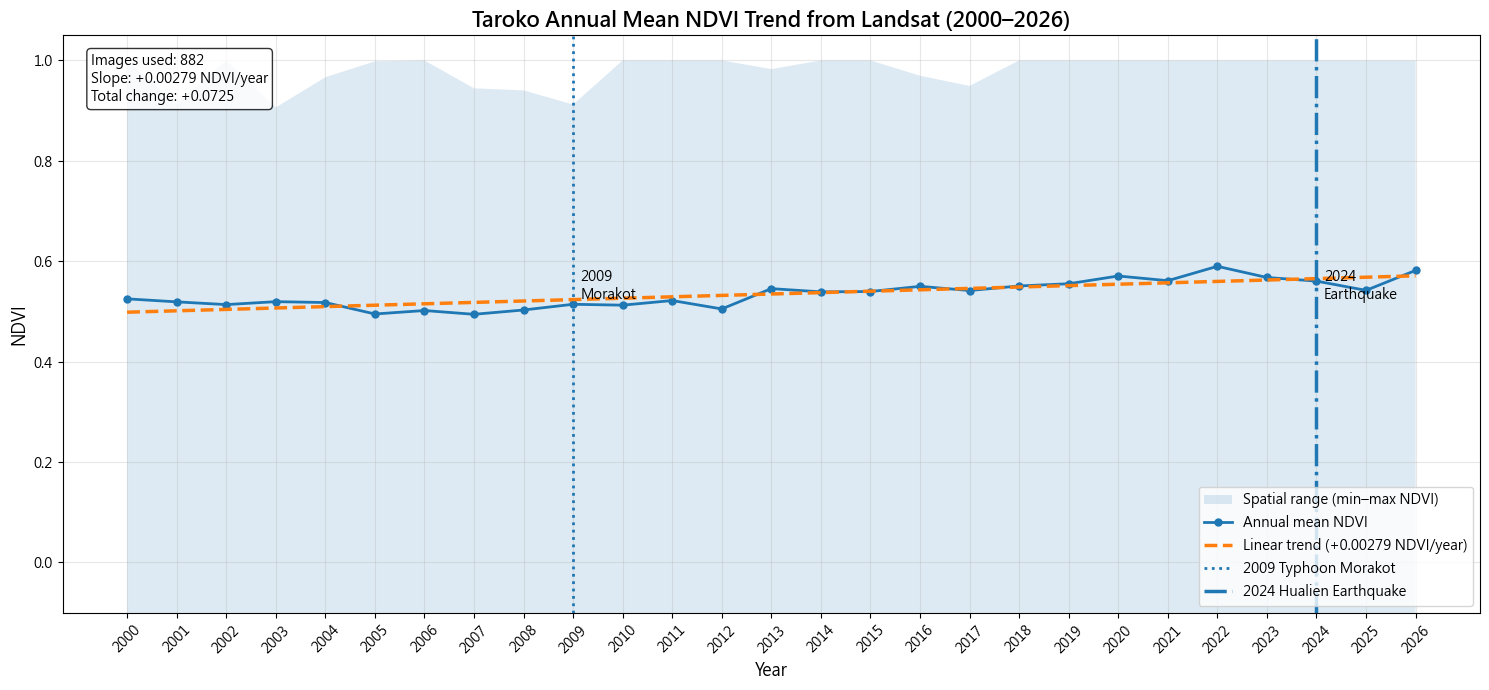

✅ NDVI trend plot saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task1_taroko_annual_ndvi_trend_2000_2026.png


In [32]:
# ============================================================
# Task 1 — Cell 7：繪製 26 年 NDVI 趨勢圖
# ============================================================

# ------------------------------------------------------------
# 1. 從 DataFrame 取出繪圖資料
# ------------------------------------------------------------
years = annual_ndvi_df["year"].to_numpy()
mean_ndvi = annual_ndvi_df["mean_NDVI"].to_numpy()
min_ndvi = annual_ndvi_df["min_NDVI"].to_numpy()
max_ndvi = annual_ndvi_df["max_NDVI"].to_numpy()

# ------------------------------------------------------------
# 2. 計算線性趨勢
# ------------------------------------------------------------
# slope 單位：NDVI / year
slope, intercept = np.polyfit(years, mean_ndvi, 1)
trend_line = slope * years + intercept

total_change = slope * (years[-1] - years[0])

print(f"26-year trend: {slope:+.5f} NDVI/year")
print(f"Total change: {total_change:+.4f} over {years[-1] - years[0]} years")

# ------------------------------------------------------------
# 3. 建立圖表
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 7))

# NDVI 空間範圍：min–max
ax.fill_between(
    years,
    min_ndvi,
    max_ndvi,
    alpha=0.15,
    label="Spatial range (min–max NDVI)"
)

# 年度平均 NDVI
ax.plot(
    years,
    mean_ndvi,
    marker="o",
    linewidth=2,
    markersize=5,
    label="Annual mean NDVI"
)

# 線性趨勢線
ax.plot(
    years,
    trend_line,
    linestyle="--",
    linewidth=2.5,
    label=f"Linear trend ({slope:+.5f} NDVI/year)"
)

# ------------------------------------------------------------
# 4. 標記重要事件年份
# ------------------------------------------------------------
ax.axvline(
    x=2009,
    linestyle=":",
    linewidth=2,
    label="2009 Typhoon Morakot"
)

ax.axvline(
    x=2024,
    linestyle="-.",
    linewidth=2.5,
    label="2024 Hualien Earthquake"
)

# 文字標籤
ax.text(
    2009 + 0.15,
    np.nanmax(mean_ndvi) - 0.005,
    "2009\nMorakot",
    fontsize=10,
    va="top"
)

ax.text(
    2024 + 0.15,
    np.nanmax(mean_ndvi) - 0.005,
    "2024\nEarthquake",
    fontsize=10,
    va="top"
)

# ------------------------------------------------------------
# 5. 圖表格式設定
# ------------------------------------------------------------
ax.set_title(
    "Taroko Annual Mean NDVI Trend from Landsat (2000–2026)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("NDVI", fontsize=12)

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.set_ylim(-0.1, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

# 加入右上角統計文字
summary_text = (
    f"Images used: {total_count}\n"
    f"Slope: {slope:+.5f} NDVI/year\n"
    f"Total change: {total_change:+.4f}"
)

ax.text(
    0.02,
    0.97,
    summary_text,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()

# ------------------------------------------------------------
# 6. 儲存圖片到 output 資料夾
# ------------------------------------------------------------
task1_plot_path = OUTPUT_DIR / "task1_taroko_annual_ndvi_trend_2000_2026.png"
plt.savefig(task1_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✅ NDVI trend plot saved to: {task1_plot_path}")

## Task 1 — Cell 8：撰寫 26 年 NDVI 趨勢分析

本 cell 會根據前一格產生的年度 NDVI 統計結果，自動整理 Task 1 所需的文字分析。

分析內容包含：

1. 26 年長期趨勢是 greening 還是 browning。
2. 2009 莫拉克颱風與 2024 花蓮地震在時間序列中的表現。
3. 2024 地震與其他年份相比是否異常。
4. W14 Landsat 影像數量與 W13 Sentinel-2 的差異。
5. 將分析文字輸出成 Markdown 檔案到 `output/` 資料夾。

In [33]:
# ============================================================
# Task 1 — Cell 8：Task 1 文字分析與 Markdown 輸出
# ============================================================

# ------------------------------------------------------------
# 1. 找出 NDVI 最高與最低年份
# ------------------------------------------------------------
min_row = annual_ndvi_df.loc[annual_ndvi_df["mean_NDVI"].idxmin()]
max_row = annual_ndvi_df.loc[annual_ndvi_df["mean_NDVI"].idxmax()]

min_year = int(min_row["year"])
min_value = float(min_row["mean_NDVI"])

max_year = int(max_row["year"])
max_value = float(max_row["mean_NDVI"])

# 取得 2009 與 2024 的 NDVI
ndvi_2009 = float(annual_ndvi_df.loc[annual_ndvi_df["year"] == 2009, "mean_NDVI"].iloc[0])
ndvi_2024 = float(annual_ndvi_df.loc[annual_ndvi_df["year"] == 2024, "mean_NDVI"].iloc[0])

# 取得整體平均
overall_mean = float(annual_ndvi_df["mean_NDVI"].mean())

# 判斷趨勢方向
trend_label_en = "greening" if slope > 0 else "browning"
trend_label_zh = "長期變綠（greening）" if slope > 0 else "長期退化（browning）"

# ------------------------------------------------------------
# 2. 建立 Task 1 分析文字
# ------------------------------------------------------------
task1_analysis_md = f"""
## Task 1 — Landsat Harmonization + 26-Year NDVI Time Series Analysis

本次分析共使用 **{total_count} 張 Landsat 影像**，整合 Landsat 5、7、8、9 四代感測器，建立 2000–2026 年太魯閣／秀林研究區的年度 NDVI 時間序列。分析前先進行波段調和，將不同 Landsat 任務的波段統一為 `Blue, Green, Red, NIR, SWIR1, SWIR2`，並套用 Collection 2 Level 2 的 surface reflectance scale factor 與 QA_PIXEL 雲／雲影遮罩。

### 1. Long-term trend：長期趨勢

從 26 年 NDVI 時序圖可以看出，研究區整體呈現 **{trend_label_zh}** 的趨勢。線性趨勢斜率為 **{slope:+.5f} NDVI/year**，代表平均每年 NDVI 約增加 {slope:.5f}。若以 2000–2026 年整段期間估算，總變化量約為 **{total_change:+.4f} NDVI**。

這表示太魯閣研究區雖然受到颱風、地震與坡地崩塌等自然擾動影響，但在長時間尺度下，整體植被狀態仍呈現緩慢改善。可能原因包括森林自然演替、植被再生、部分受損區域逐漸恢復，以及大面積未受損森林區對整體平均值的穩定作用。

### 2. Anomalous years：異常年份

在年度平均 NDVI 中，最低值出現在 **{min_year} 年**，平均 NDVI 約為 **{min_value:.4f}**；最高值出現在 **{max_year} 年**，平均 NDVI 約為 **{max_value:.4f}**。整體平均 NDVI 約為 **{overall_mean:.4f}**。

2009 年莫拉克颱風對台灣山區造成重大坡地災害，但在本研究區年度平均 NDVI 中，2009 年 NDVI 約為 **{ndvi_2009:.4f}**，並未出現非常劇烈的整體下降。這可能是因為本分析使用年度 median composite 和整個 AOI 的平均值，因此局部崩塌訊號可能被大範圍穩定森林區所稀釋。

### 3. 2024 earthquake context：2024 地震脈絡

2024 年花蓮地震當年的平均 NDVI 約為 **{ndvi_2024:.4f}**。從圖上來看，2024 年並不是 26 年中最低的 NDVI 年份，表示地震雖然可能造成局部崩塌、裸露地增加與河谷擾動，但以整個研究區尺度來看，其影響尚未完全壓過長期植被變綠趨勢。

因此，2024 年地震需要搭配更細尺度的 ΔNDVI、slope map 或 Sentinel-2 10 m 影像進一步觀察，才能判斷哪些局部區域受到最嚴重影響。

### 4. Landsat vs Sentinel-2：時間尺度差異

相較於 W13 使用 Sentinel-2 進行約 6 年的高解析度時序分析，W14 使用 Landsat 將時間範圍延長至 **26 年**。Sentinel-2 的優勢是 10 m 空間解析度高，適合觀察災後細節；Landsat 的優勢則是時間序列長，適合建立長期背景與判斷趨勢。

換句話說，Sentinel-2 較適合回答「地震後哪裡改變了？」，而 Landsat 更適合回答「這個改變在過去 26 年中是否異常？」。
"""

print(task1_analysis_md)

# ------------------------------------------------------------
# 3. 輸出 Markdown 檔案到 output 資料夾
# ------------------------------------------------------------
task1_analysis_path = OUTPUT_DIR / "task1_ndvi_trend_analysis.md"

with open(task1_analysis_path, "w", encoding="utf-8") as f:
    f.write(task1_analysis_md)

print(f"\n✅ Task 1 analysis saved to: {task1_analysis_path}")


## Task 1 — Landsat Harmonization + 26-Year NDVI Time Series Analysis

本次分析共使用 **882 張 Landsat 影像**，整合 Landsat 5、7、8、9 四代感測器，建立 2000–2026 年太魯閣／秀林研究區的年度 NDVI 時間序列。分析前先進行波段調和，將不同 Landsat 任務的波段統一為 `Blue, Green, Red, NIR, SWIR1, SWIR2`，並套用 Collection 2 Level 2 的 surface reflectance scale factor 與 QA_PIXEL 雲／雲影遮罩。

### 1. Long-term trend：長期趨勢

從 26 年 NDVI 時序圖可以看出，研究區整體呈現 **長期變綠（greening）** 的趨勢。線性趨勢斜率為 **+0.00279 NDVI/year**，代表平均每年 NDVI 約增加 0.00279。若以 2000–2026 年整段期間估算，總變化量約為 **+0.0725 NDVI**。

這表示太魯閣研究區雖然受到颱風、地震與坡地崩塌等自然擾動影響，但在長時間尺度下，整體植被狀態仍呈現緩慢改善。可能原因包括森林自然演替、植被再生、部分受損區域逐漸恢復，以及大面積未受損森林區對整體平均值的穩定作用。

### 2. Anomalous years：異常年份

在年度平均 NDVI 中，最低值出現在 **2007 年**，平均 NDVI 約為 **0.4942**；最高值出現在 **2022 年**，平均 NDVI 約為 **0.5898**。整體平均 NDVI 約為 **0.5346**。

2009 年莫拉克颱風對台灣山區造成重大坡地災害，但在本研究區年度平均 NDVI 中，2009 年 NDVI 約為 **0.5141**，並未出現非常劇烈的整體下降。這可能是因為本分析使用年度 median composite 和整個 AOI 的平均值，因此局部崩塌訊號可能被大範圍穩定森林區所稀釋。

### 3. 2024 earthquake context：2024 地震脈絡

2024 年花蓮地震當年的平均 NDVI 約為 **0.5603**。從圖上來看，2024 年並不是 26 年

## Task 2 — Pixel-Level Linear Trend Analysis  
### Cell 9：建立年度 NDVI ImageCollection 與時間 band

本 cell 會正式開始 Task 2。  
目標是把 2000–2026 年每一年的 Landsat NDVI 影像，轉換成一個年度尺度的 `ImageCollection`。

每一年會產生一張年度 NDVI 中位數影像，並額外加入一個 `time` band。  
這個 `time` band 代表年份，例如 2000、2001、2002……2026。

後續 `ee.Reducer.linearFit()` 會使用：

- `time` 作為自變數 x
- `NDVI` 作為應變數 y

藉此對每個像素計算 26 年 NDVI 線性趨勢，也就是 greening / browning 的空間分布。

In [34]:
# ============================================================
# Task 2 — Cell 9：建立年度 NDVI ImageCollection 與時間 band
# ============================================================

# ------------------------------------------------------------
# 1. 建立單一年份的年度 NDVI 影像函數
# ------------------------------------------------------------
def annual_ndvi_image(year):
    """
    Create an annual median NDVI image with a time band.

    Parameters
    ----------
    year : ee.Number
        Target year.

    Returns
    -------
    ee.Image
        Image with two bands:
        - time: year value, used as independent variable
        - NDVI: annual median NDVI, used as dependent variable
    """
    year = ee.Number(year).int()

    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)

    # 年度 NDVI median composite
    annual_ndvi = (
        ndvi_collection
        .filterDate(start, end)
        .median()
        .rename("NDVI")
    )

    # time band：使用實際年份作為 linearFit 的 x 變數
    time_band = ee.Image.constant(year).float().rename("time")

    return (
        time_band
        .addBands(annual_ndvi)
        .set("year", year)
        .set("system:time_start", start.millis())
    )


# ------------------------------------------------------------
# 2. 建立 2000–2026 年年度 NDVI ImageCollection
# ------------------------------------------------------------
year_list = ee.List.sequence(START_YEAR, END_YEAR)

annual_ndvi_col = ee.ImageCollection(
    year_list.map(annual_ndvi_image)
)

# ------------------------------------------------------------
# 3. 檢查年度 ImageCollection
# ------------------------------------------------------------
annual_count = annual_ndvi_col.size().getInfo()
first_annual_bands = annual_ndvi_col.first().bandNames().getInfo()
first_annual_year = annual_ndvi_col.first().get("year").getInfo()

print("Annual NDVI ImageCollection created.")
print("Number of annual images:", annual_count)
print("First annual image year:", first_annual_year)
print("Bands:", first_annual_bands)

# ------------------------------------------------------------
# 4. 快速顯示第一年年度 NDVI composite
# ------------------------------------------------------------
Map_task2_check = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_task2_check.add_basemap("OpenStreetMap")

Map_task2_check.addLayer(
    annual_ndvi_col.first().select("NDVI"),
    {
        "min": 0,
        "max": 0.8,
        "palette": ["brown", "yellow", "lightgreen", "darkgreen"]
    },
    f"Annual NDVI {START_YEAR}"
)

Map_task2_check.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

Map_task2_check

Annual NDVI ImageCollection created.
Number of annual images: 27
First annual image year: 2000
Bands: ['time', 'NDVI']


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 2 — Cell 10：計算 Pixel-Level NDVI Linear Trend

本 cell 會使用上一格建立的 `annual_ndvi_col`，對每個像素進行 2000–2026 年 NDVI 線性迴歸。

線性模型為：

`NDVI = slope × time + offset`

其中：

- `time`：年份，例如 2000、2001、...、2026
- `NDVI`：該年度的年度中位數 NDVI
- `slope`：每年 NDVI 的變化量，也就是 greening / browning 趨勢
- `offset`：線性迴歸截距

判讀方式：

- `slope > 0`：長期變綠，可能代表植被恢復或森林演替
- `slope < 0`：長期退化，可能代表崩塌、裸露、河道侵蝕或都市化
- `slope ≈ 0`：長期穩定

本 cell 會建立 `trend`、`slope`、`offset` 三個變數，供後續繪圖、統計與 GeoTIFF 匯出使用。

In [35]:
# ============================================================
# Task 2 — Cell 10：使用 linearFit 計算 NDVI pixel-level trend
# ============================================================

# ------------------------------------------------------------
# 1. 使用 ee.Reducer.linearFit() 計算每個像素的線性趨勢
# ------------------------------------------------------------
# 注意 band 順序：
#   select(['time', 'NDVI'])
#
# linearFit 會把第一個 band 視為 x，自變數
# 第二個 band 視為 y，應變數
#
# 輸出：
#   scale  = slope
#   offset = intercept

trend = (
    annual_ndvi_col
    .select(["time", "NDVI"])
    .reduce(ee.Reducer.linearFit())
)

# ------------------------------------------------------------
# 2. 取出 slope 與 offset
# ------------------------------------------------------------
slope = trend.select("scale").rename("NDVI_slope")
offset = trend.select("offset").rename("NDVI_offset")

# ------------------------------------------------------------
# 3. 裁切至 AOI，避免顯示整張影像範圍
# ------------------------------------------------------------
trend = trend.clip(aoi)
slope = slope.clip(aoi)
offset = offset.clip(aoi)

# ------------------------------------------------------------
# 4. 檢查 trend 影像波段
# ------------------------------------------------------------
trend_bands = trend.bandNames().getInfo()
print("Trend image bands:", trend_bands)
print("Slope band name:", slope.bandNames().getInfo())
print("Offset band name:", offset.bandNames().getInfo())

# ------------------------------------------------------------
# 5. 計算 slope 在 AOI 內的基本統計
# ------------------------------------------------------------
slope_stats = slope.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
        .combine(reducer2=ee.Reducer.max(), sharedInputs=True),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

print("\nNDVI slope statistics within AOI:")
print(f"  Mean slope: {slope_stats.get('NDVI_slope_mean'):+.6f} NDVI/year")
print(f"  Min slope : {slope_stats.get('NDVI_slope_min'):+.6f} NDVI/year")
print(f"  Max slope : {slope_stats.get('NDVI_slope_max'):+.6f} NDVI/year")

print("\n✅ Pixel-level NDVI linear trend is ready.")

Trend image bands: ['scale', 'offset']
Slope band name: ['NDVI_slope']
Offset band name: ['NDVI_offset']

NDVI slope statistics within AOI:
  Mean slope: +0.002898 NDVI/year
  Min slope : -0.041139 NDVI/year
  Max slope : +0.042821 NDVI/year

✅ Pixel-level NDVI linear trend is ready.


## Task 2 — Cell 11：視覺化 Greening / Browning Slope Map

本 cell 會將上一格計算出的 `NDVI_slope` 轉成地圖圖層。

圖層判讀方式：

- 紅色：NDVI slope < 0，代表長期 browning，可能是崩塌、裸露地、河道侵蝕或植被退化。
- 白色：NDVI slope 接近 0，代表長期穩定。
- 綠色：NDVI slope > 0，代表長期 greening，可能是植被恢復、森林演替或再生。

本 cell 會建立互動式地圖，並輸出成 HTML 到 `output/` 資料夾，方便作業繳交時附上結果截圖。

In [36]:
# ============================================================
# Task 2 — Cell 11：視覺化 NDVI Slope Map 並輸出 HTML
# ============================================================

# ------------------------------------------------------------
# 1. 設定 slope map 視覺化參數
# ------------------------------------------------------------
# 根據目前 AOI 內 slope 統計：
# Mean slope 約 +0.0029
# Min / Max 約 -0.04 ~ +0.04
#
# 為了讓主要趨勢更清楚，視覺化範圍使用 -0.01 ~ +0.01
# 若想看極端變化，可改成 -0.03 ~ +0.03

slope_vis = {
    "min": -0.01,
    "max": 0.01,
    "palette": [
        "8c2d04",  # strong browning
        "d94801",
        "fdae6b",
        "ffffcc",  # stable / near zero
        "a1d99b",
        "31a354",
        "006d2c"   # strong greening
    ]
}

# ------------------------------------------------------------
# 2. 建立互動地圖
# ------------------------------------------------------------
Map_slope = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_slope.add_basemap("OpenStreetMap")

# 加入 slope map
Map_slope.addLayer(
    slope,
    slope_vis,
    "NDVI slope 2000–2026 (greening / browning)"
)

# 加入 AOI 邊界
Map_slope.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

# 加入圖層控制
Map_slope.addLayerControl()

# ------------------------------------------------------------
# 3. 輸出互動式地圖為 HTML
# ------------------------------------------------------------
task2_slope_html = OUTPUT_DIR / "task2_taroko_ndvi_slope_map.html"
Map_slope.to_html(str(task2_slope_html))

print(f"✅ Slope map HTML saved to: {task2_slope_html}")

Map_slope

✅ Slope map HTML saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task2_taroko_ndvi_slope_map.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 2 — Cell 12：統計 Greening / Browning / Stable 像素比例

本 cell 會根據 Task 2 的 NDVI slope map，將研究區內每個像素分類為三種趨勢：

1. **Greening**：`slope > 0.001`  
   表示 26 年內 NDVI 有明顯上升，可能代表植被恢復、森林演替或綠化增加。

2. **Browning**：`slope < -0.001`  
   表示 26 年內 NDVI 有明顯下降，可能代表崩塌、裸露地增加、河道侵蝕或植被退化。

3. **Stable**：`-0.001 <= slope <= 0.001`  
   表示 NDVI 長期變化不明顯，屬於相對穩定區域。

本 cell 會計算三類像素面積與百分比，並將結果輸出成 CSV 到 `output/` 資料夾，作為 Task 2 的必要統計成果。

In [37]:
# ============================================================
# Task 2 — Cell 12：Greening / Browning / Stable 像素統計
# ============================================================

# ------------------------------------------------------------
# 1. 設定 slope 分類門檻
# ------------------------------------------------------------
# slope 單位：NDVI / year
# 這裡使用 homework 建議值：
# >  0.001 = greening
# < -0.001 = browning
# 其餘 = stable

GREENING_TH = 0.001
BROWNING_TH = -0.001

greening = slope.gt(GREENING_TH).rename("greening")
browning = slope.lt(BROWNING_TH).rename("browning")
stable = slope.gte(BROWNING_TH).And(slope.lte(GREENING_TH)).rename("stable")

# ------------------------------------------------------------
# 2. 建立像素面積影像
# ------------------------------------------------------------
pixel_area = ee.Image.pixelArea()

greening_area_img = greening.multiply(pixel_area).rename("greening_area")
browning_area_img = browning.multiply(pixel_area).rename("browning_area")
stable_area_img = stable.multiply(pixel_area).rename("stable_area")

# 有效 NDVI slope 像素面積
valid_area_img = slope.mask().multiply(pixel_area).rename("valid_area")

# ------------------------------------------------------------
# 3. 在 AOI 內計算各類別面積
# ------------------------------------------------------------
area_image = (
    greening_area_img
    .addBands(browning_area_img)
    .addBands(stable_area_img)
    .addBands(valid_area_img)
)

area_stats = area_image.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

# ------------------------------------------------------------
# 4. 面積單位轉換：m² → km²
# ------------------------------------------------------------
greening_area_km2 = area_stats["greening_area"] / 1e6
browning_area_km2 = area_stats["browning_area"] / 1e6
stable_area_km2 = area_stats["stable_area"] / 1e6
valid_area_km2 = area_stats["valid_area"] / 1e6

greening_pct = greening_area_km2 / valid_area_km2 * 100
browning_pct = browning_area_km2 / valid_area_km2 * 100
stable_pct = stable_area_km2 / valid_area_km2 * 100

# ------------------------------------------------------------
# 5. 整理成 DataFrame
# ------------------------------------------------------------
trend_stats_df = pd.DataFrame([
    {
        "class": "Greening",
        "condition": f"slope > {GREENING_TH}",
        "area_km2": greening_area_km2,
        "percentage": greening_pct
    },
    {
        "class": "Browning",
        "condition": f"slope < {BROWNING_TH}",
        "area_km2": browning_area_km2,
        "percentage": browning_pct
    },
    {
        "class": "Stable",
        "condition": f"{BROWNING_TH} <= slope <= {GREENING_TH}",
        "area_km2": stable_area_km2,
        "percentage": stable_pct
    }
])

display(trend_stats_df)

print("Total valid area:", f"{valid_area_km2:.2f} km²")
print(f"Greening: {greening_pct:.2f}%")
print(f"Browning: {browning_pct:.2f}%")
print(f"Stable  : {stable_pct:.2f}%")

# ------------------------------------------------------------
# 6. 輸出 CSV 到 output 資料夾
# ------------------------------------------------------------
trend_stats_csv = OUTPUT_DIR / "task2_taroko_ndvi_trend_class_statistics.csv"
trend_stats_df.to_csv(trend_stats_csv, index=False, encoding="utf-8-sig")

print(f"\n✅ Task 2 trend class statistics saved to: {trend_stats_csv}")

,class,condition,area_km2,percentage
0,Greening,slope > 0.001,1466.895306,82.665642
1,Browning,slope < -0.001,83.794910,4.722191
2,Stable,-0.001 <= slope <= 0.001,224.602408,12.657278


Total valid area: 1774.49 km²
Greening: 82.67%
Browning: 4.72%
Stable  : 12.66%

✅ Task 2 trend class statistics saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task2_taroko_ndvi_trend_class_statistics.csv


## Task 2 — Cell 13：建立 NDVI Trend Classification Map

本 cell 會將連續型的 `NDVI_slope` 轉換為類別型地圖，方便判讀太魯閣研究區內哪些區域屬於長期變綠、長期退化或相對穩定。

分類規則如下：

- `1 = Browning`：slope < -0.001
- `2 = Stable`：-0.001 <= slope <= 0.001
- `3 = Greening`：slope > 0.001

這張分類圖比連續型 slope map 更容易用於報告，因為它直接呈現各區域的長期趨勢類別。  
本 cell 也會將互動式地圖輸出成 HTML，方便後續截圖放入作業。

In [38]:
# ============================================================
# Task 2 — Cell 13：建立 Greening / Stable / Browning 分類地圖
# ============================================================

# ------------------------------------------------------------
# 1. 建立分類影像
# ------------------------------------------------------------
# 類別定義：
# 1 = Browning
# 2 = Stable
# 3 = Greening

trend_class = (
    ee.Image(0)
    .where(slope.lt(BROWNING_TH), 1)
    .where(slope.gte(BROWNING_TH).And(slope.lte(GREENING_TH)), 2)
    .where(slope.gt(GREENING_TH), 3)
    .updateMask(slope.mask())
    .clip(aoi)
    .rename("trend_class")
)

# ------------------------------------------------------------
# 2. 設定分類圖視覺化參數
# ------------------------------------------------------------
trend_class_vis = {
    "min": 1,
    "max": 3,
    "palette": [
        "d73027",  # 1 Browning = red
        "f7f7f7",  # 2 Stable = white / light gray
        "1a9850"   # 3 Greening = green
    ]
}

# ------------------------------------------------------------
# 3. 建立互動地圖
# ------------------------------------------------------------
Map_trend_class = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_trend_class.add_basemap("OpenStreetMap")

Map_trend_class.addLayer(
    trend_class,
    trend_class_vis,
    "Trend class: Browning / Stable / Greening"
)

Map_trend_class.addLayer(
    aoi,
    {"color": "black"},
    "Taroko AOI"
)

Map_trend_class.addLayerControl()

# ------------------------------------------------------------
# 4. 輸出 HTML 到 output 資料夾
# ------------------------------------------------------------
task2_class_html = OUTPUT_DIR / "task2_taroko_ndvi_trend_class_map.html"
Map_trend_class.to_html(str(task2_class_html))

print(f"✅ Trend class map HTML saved to: {task2_class_html}")

Map_trend_class

✅ Trend class map HTML saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task2_taroko_ndvi_trend_class_map.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 2 — Cell 14：Trend Map 統計解讀與 W13/W14 比較

本 cell 會根據前面計算出的 `trend_stats_df`，自動產生 Task 2 所需的文字分析。

分析內容包含：

1. 太魯閣研究區中 greening、browning、stable 的比例。
2. NDVI slope map 的空間意義。
3. 26 年 Landsat 長期趨勢與 W13 6 年 Sentinel-2 短期趨勢的差異。
4. 將分析文字輸出成 Markdown 檔案到 `output/` 資料夾。

這段文字可以直接放入 notebook 的 Markdown cell，作為 Task 2 的分析回答。

In [39]:
# ============================================================
# Task 2 — Cell 14：Task 2 文字分析與 W13 vs W14 比較
# ============================================================

# ------------------------------------------------------------
# 1. 從 trend_stats_df 取出統計數值
# ------------------------------------------------------------
greening_row = trend_stats_df.loc[trend_stats_df["class"] == "Greening"].iloc[0]
browning_row = trend_stats_df.loc[trend_stats_df["class"] == "Browning"].iloc[0]
stable_row = trend_stats_df.loc[trend_stats_df["class"] == "Stable"].iloc[0]

greening_area = float(greening_row["area_km2"])
browning_area = float(browning_row["area_km2"])
stable_area = float(stable_row["area_km2"])

greening_pct = float(greening_row["percentage"])
browning_pct = float(browning_row["percentage"])
stable_pct = float(stable_row["percentage"])

# ------------------------------------------------------------
# 2. 建立文字分析
# ------------------------------------------------------------
task2_analysis_md = f"""
## Task 2 — Pixel-Level Linear Trend Analysis

本任務使用 `ee.Reducer.linearFit()` 對太魯閣研究區 2000–2026 年的年度 NDVI 影像進行像素層級線性趨勢分析。每個像素都建立一條 `NDVI = slope × time + offset` 的線性迴歸式，其中 `slope` 代表該像素每年的 NDVI 變化量。

### 1. Greening / Browning / Stable 統計結果

本次分類門檻設定為：

```text
Greening: slope > {GREENING_TH}
Browning: slope < {BROWNING_TH}
Stable: {BROWNING_TH} <= slope <= {GREENING_TH}
統計結果如下：

Class	Area (km²)	Percentage
Greening	{greening_area:.2f}	{greening_pct:.2f}%
Browning	{browning_area:.2f}	{browning_pct:.2f}%
Stable	{stable_area:.2f}	{stable_pct:.2f}%

結果顯示，太魯閣研究區有 {greening_pct:.2f}% 的有效像素呈現長期 greening，只有 {browning_pct:.2f}% 呈現長期 browning，另有 {stable_pct:.2f}% 屬於相對穩定區域。這表示從 26 年尺度來看，研究區整體以植被恢復或長期變綠為主。

2. Slope Map 空間判讀

在 slope map 中，綠色區域代表 NDVI 長期增加，可能與森林自然演替、災後植被恢復或裸露地逐漸再植生有關。紅色區域則代表 NDVI 長期下降，可能與坡面崩塌、河道沖刷、裸露岩盤增加、道路或聚落周邊開發有關。

由於 browning 像素比例相對較低，這些退化區很可能不是整體性植被退化，而是集中在局部地形敏感區，例如河谷邊坡、崩塌帶、裸露地或受反覆擾動的坡面。

3. W13 6-year Sentinel-2 vs W14 26-year Landsat

W13 使用 Sentinel-2 進行約 6 年的高解析度時序分析，優點是空間解析度高，可以看見較細的災後變化，例如個別崩塌面、道路邊坡破壞或河道細部變化。然而，6 年時間窗較短，容易受到單一事件、季節差異或雲遮罩品質影響，因此不一定能代表長期趨勢。

W14 使用 Landsat 建立 26 年長期時序，雖然空間解析度較粗，但能夠分辨短期波動與長期訊號。本次結果顯示，太魯閣研究區即使受到颱風與地震等擾動，整體仍以 greening 為主。這說明若只看 W13 的短期 Sentinel-2 變化，可能會強調災後局部退化；但若放到 W14 的 26 年 Landsat 脈絡中，則可以看見生態系長期恢復與韌性的背景。

4. 小結

Task 2 的結果顯示，長期趨勢圖能夠回答「哪些區域正在長期變綠或退化」的問題。它不只是災後變化偵測，而是把每個像素的 26 年歷史壓縮成一個 slope 值，讓我們能從空間上辨識長期 greening、browning 與 stable 區域。
"""

print(task2_analysis_md)

#------------------------------------------------------------
# 3. 輸出 Markdown 到 output 資料夾
#------------------------------------------------------------

task2_analysis_path = OUTPUT_DIR / "task2_ndvi_trend_analysis.md"

with open(task2_analysis_path, "w", encoding="utf-8") as f:
    f.write(task2_analysis_md)

print(f"\n✅ Task 2 analysis saved to: {task2_analysis_path}")


## Task 2 — Pixel-Level Linear Trend Analysis

本任務使用 `ee.Reducer.linearFit()` 對太魯閣研究區 2000–2026 年的年度 NDVI 影像進行像素層級線性趨勢分析。每個像素都建立一條 `NDVI = slope × time + offset` 的線性迴歸式，其中 `slope` 代表該像素每年的 NDVI 變化量。

### 1. Greening / Browning / Stable 統計結果

本次分類門檻設定為：

```text
Greening: slope > 0.001
Browning: slope < -0.001
Stable: -0.001 <= slope <= 0.001
統計結果如下：

Class	Area (km²)	Percentage
Greening	1466.90	82.67%
Browning	83.79	4.72%
Stable	224.60	12.66%

結果顯示，太魯閣研究區有 82.67% 的有效像素呈現長期 greening，只有 4.72% 呈現長期 browning，另有 12.66% 屬於相對穩定區域。這表示從 26 年尺度來看，研究區整體以植被恢復或長期變綠為主。

2. Slope Map 空間判讀

在 slope map 中，綠色區域代表 NDVI 長期增加，可能與森林自然演替、災後植被恢復或裸露地逐漸再植生有關。紅色區域則代表 NDVI 長期下降，可能與坡面崩塌、河道沖刷、裸露岩盤增加、道路或聚落周邊開發有關。

由於 browning 像素比例相對較低，這些退化區很可能不是整體性植被退化，而是集中在局部地形敏感區，例如河谷邊坡、崩塌帶、裸露地或受反覆擾動的坡面。

3. W13 6-year Sentinel-2 vs W14 26-year Landsat

W13 使用 Sentinel-2 進行約 6 年的高解析度時序分析，優點是空間解析度高，可以看見較細的災後變化，例如個別崩塌面、道路邊坡破壞或河道細部變化。然而，6 年時間窗較短，容易受到單一事件、季節差異或雲遮罩品質影響，因此不一定能代表長期趨勢。

W14 使用 Landsat 建立 26 年長期時序，雖然空間解析度較粗，但能夠分辨短期波動與長期訊號

## Task 2 — Cell 15：匯出 NDVI Trend GeoTIFF

本 cell 會將 Task 2 產生的 NDVI 長期趨勢結果匯出為 GeoTIFF。

匯出內容包含：

1. `NDVI_slope`：每個像素的 NDVI 年變化率
2. `NDVI_offset`：線性迴歸截距
3. `trend_class`：趨勢分類結果  
   - 1 = Browning  
   - 2 = Stable  
   - 3 = Greening  

作業要求至少需要匯出 trend map，並提供 Google Drive 中匯出檔案的截圖。  
本 cell 會把 GeoTIFF 匯出到 Google Drive 的 `GEE_Exports` 資料夾，CRS 使用作業指定的 `EPSG:32651`。

In [40]:
# ============================================================
# Task 2 — Cell 15：匯出 NDVI Trend GeoTIFF 到 Google Drive
# ============================================================

# ------------------------------------------------------------
# 1. 整合要匯出的 band
# ------------------------------------------------------------
# 包含：
# - NDVI_slope：每年 NDVI 變化量
# - NDVI_offset：線性迴歸截距
# - trend_class：1 browning, 2 stable, 3 greening

trend_export = (
    slope
    .addBands(offset)
    .addBands(trend_class)
    .toFloat()
    .clip(aoi)
)

print("Export image bands:", trend_export.bandNames().getInfo())

# ------------------------------------------------------------
# 2. 設定 Google Drive 匯出任務
# ------------------------------------------------------------
# 注意：
# 這個 task.start() 執行後，請到 GEE Tasks 或 Google Drive 確認匯出狀態。
# 匯出完成後，請對 Google Drive 中的 GeoTIFF 檔案截圖，作為作業繳交證明。

task2_export_task = ee.batch.Export.image.toDrive(
    image=trend_export,
    description="task2_taroko_ndvi_trend_26yr",
    folder="GEE_Exports",
    fileNamePrefix="task2_taroko_ndvi_trend_26yr",
    region=aoi,
    scale=30,
    crs="EPSG:32651",
    maxPixels=1e9
)

task2_export_task.start()

print("✅ Export task started.")
print("Description : task2_taroko_ndvi_trend_26yr")
print("Drive folder: GEE_Exports")
print("CRS         : EPSG:32651")
print("Scale       : 30 m")
print("\n請到 Google Earth Engine Tasks 或 Google Drive 檢查匯出進度。")

Export image bands: ['NDVI_slope', 'NDVI_offset', 'trend_class']
✅ Export task started.
Description : task2_taroko_ndvi_trend_26yr
Drive folder: GEE_Exports
CRS         : EPSG:32651
Scale       : 30 m

請到 Google Earth Engine Tasks 或 Google Drive 檢查匯出進度。


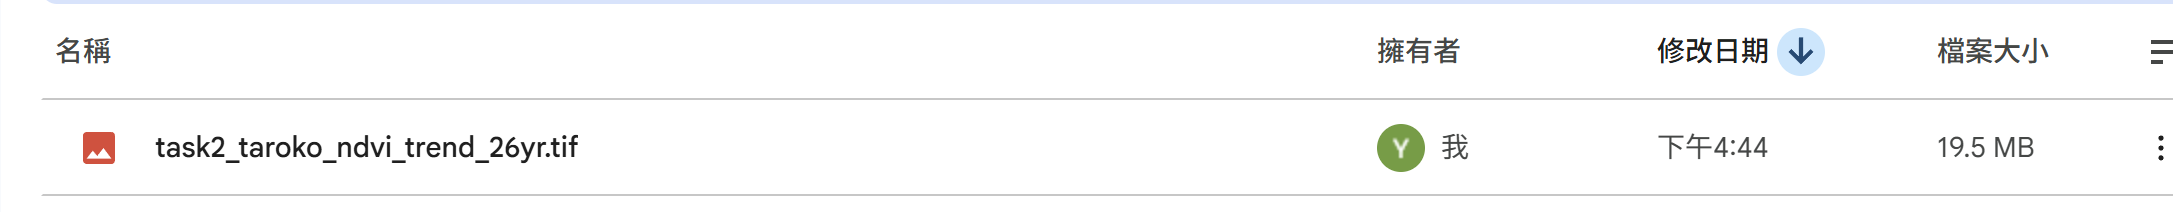

## Task 3 — Taoyuan Pond Disappearance with MNDWI  
### Cell 16：定義桃園研究區與載入 Landsat 影像

本 cell 會正式開始 Task 3：桃園埤塘消失分析。

這個任務會使用 MNDWI 偵測 2000–2026 年桃園台地的水體變化。  
本 cell 會先建立兩個桃園研究區：

1. `aoi_taoyuan`：桃園完整範圍，用於製作 26 年 water frequency map。
2. `aoi_taoyuan_urban`：都市化走廊，用於比較早期與近期的埤塘消失區。

接著會重新載入桃園範圍內的 Landsat 5、7、8、9 影像，並套用前面已經建立好的 band harmonization、scale factor 和 QA_PIXEL 雲遮罩函數。

In [41]:
# ============================================================
# Task 3 — Cell 16：定義桃園研究區並載入 Landsat 影像
# ============================================================

# ------------------------------------------------------------
# 1. 定義桃園研究區
# ------------------------------------------------------------
# 桃園完整範圍：用於 water frequency map
TAOYUAN_BBOX = [
    120.94,  # west
    24.83,   # south
    121.35,  # east
    25.08    # north
]

aoi_taoyuan = ee.Geometry.Rectangle(TAOYUAN_BBOX)

# 桃園都市化走廊：用於 pond disappearance change detection
TAOYUAN_URBAN_BBOX = [
    121.00,  # west
    24.88,   # south
    121.28,  # east
    25.05    # north
]

aoi_taoyuan_urban = ee.Geometry.Rectangle(TAOYUAN_URBAN_BBOX)

print("Taoyuan full AOI:", TAOYUAN_BBOX)
print("Taoyuan urban corridor AOI:", TAOYUAN_URBAN_BBOX)

# ------------------------------------------------------------
# 2. 載入桃園範圍 Landsat 5 / 7 / 8 / 9
# ------------------------------------------------------------
l5_ty = (
    ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2000-01-01", "2012-12-31")
    .map(harmonize_l57)
)

l7_ty = (
    ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2000-01-01", "2026-12-31")
    .map(harmonize_l57)
)

l8_ty = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2013-01-01", "2026-12-31")
    .map(harmonize_l89)
)

l9_ty = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(aoi_taoyuan)
    .filterDate("2021-01-01", "2026-12-31")
    .map(harmonize_l89)
)

# ------------------------------------------------------------
# 3. 合併並套用 scale factor + cloud mask
# ------------------------------------------------------------
landsat_taoyuan = (
    l5_ty
    .merge(l7_ty)
    .merge(l8_ty)
    .merge(l9_ty)
    .map(apply_scale_and_mask)
)

# ------------------------------------------------------------
# 4. 檢查影像數量
# ------------------------------------------------------------
l5_ty_count = l5_ty.size().getInfo()
l7_ty_count = l7_ty.size().getInfo()
l8_ty_count = l8_ty.size().getInfo()
l9_ty_count = l9_ty.size().getInfo()
taoyuan_total_count = landsat_taoyuan.size().getInfo()

print("\nTaoyuan Landsat image count before scale/mask:")
print(f"  Landsat 5 : {l5_ty_count}")
print(f"  Landsat 7 : {l7_ty_count}")
print(f"  Landsat 8 : {l8_ty_count}")
print(f"  Landsat 9 : {l9_ty_count}")
print("-" * 45)
print(f"Total Taoyuan Landsat images after merge: {taoyuan_total_count}")

print("\nBands:", landsat_taoyuan.first().bandNames().getInfo())

# ------------------------------------------------------------
# 5. 顯示桃園 AOI 檢查地圖
# ------------------------------------------------------------
Map_ty = geemap.Map(center=[24.97, 121.15], zoom=10)
Map_ty.add_basemap("OpenStreetMap")

Map_ty.addLayer(
    aoi_taoyuan,
    {"color": "blue"},
    "Taoyuan full AOI"
)

Map_ty.addLayer(
    aoi_taoyuan_urban,
    {"color": "red"},
    "Taoyuan urban corridor AOI"
)

Map_ty.addLayerControl()

print("\n✅ Taoyuan Landsat collection is ready.")

Map_ty

Taoyuan full AOI: [120.94, 24.83, 121.35, 25.08]
Taoyuan urban corridor AOI: [121.0, 24.88, 121.28, 25.05]

Taoyuan Landsat image count before scale/mask:
  Landsat 5 : 511
  Landsat 7 : 1050
  Landsat 8 : 710
  Landsat 9 : 227
---------------------------------------------
Total Taoyuan Landsat images after merge: 2498

Bands: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

✅ Taoyuan Landsat collection is ready.


Map(center=[24.97, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Task 3 — Cell 17：計算 MNDWI 與 Water Frequency Map

本 cell 會計算桃園範圍內每張 Landsat 影像的 MNDWI，並建立 2000–2026 年的年度水體遮罩。

MNDWI 公式為：

`MNDWI = (Green - SWIR1) / (Green + SWIR1)`

判斷規則：

- `MNDWI > 0.1`：判定為水體
- `MNDWI <= 0.1`：判定為非水體

接著，程式會統計每個像素在 27 年中有多少比例被判定為水體，得到 `water_freq`。  
這張圖可以用來判斷哪些地方是穩定存在的埤塘，哪些地方可能是季節性水體、縮小水體或已消失埤塘。

In [42]:
# ============================================================
# Task 3 — Cell 17：計算 MNDWI 與 Water Frequency Map
# ============================================================

# ------------------------------------------------------------
# 1. 設定 MNDWI 水體判定門檻
# ------------------------------------------------------------
MNDWI_WATER_TH = 0.1

# ------------------------------------------------------------
# 2. 定義 MNDWI 計算函數
# ------------------------------------------------------------
def add_mndwi(image):
    """
    Add MNDWI band to each Landsat image.

    MNDWI = (Green - SWIR1) / (Green + SWIR1)

    Higher MNDWI values indicate water bodies.
    """
    mndwi = image.normalizedDifference(["Green", "SWIR1"]).rename("MNDWI")

    return (
        image
        .addBands(mndwi)
        .copyProperties(image, ["system:time_start"])
    )


# ------------------------------------------------------------
# 3. 對桃園 Landsat 影像集合計算 MNDWI
# ------------------------------------------------------------
landsat_taoyuan_idx = landsat_taoyuan.map(add_mndwi)
mndwi_taoyuan = landsat_taoyuan_idx.select("MNDWI")

print("MNDWI collection size:", mndwi_taoyuan.size().getInfo())
print("Bands:", mndwi_taoyuan.first().bandNames().getInfo())

# ------------------------------------------------------------
# 4. 建立單一年份的年度水體遮罩
# ------------------------------------------------------------
def yearly_water_mask(year):
    """
    Create annual water mask for one year.

    Steps:
    1. Filter MNDWI images within the year
    2. Create annual median MNDWI composite
    3. Classify water using MNDWI > threshold
    """
    year = ee.Number(year).int()

    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)

    annual_mndwi = (
        mndwi_taoyuan
        .filterDate(start, end)
        .median()
        .rename("MNDWI")
    )

    water = (
        annual_mndwi
        .gt(MNDWI_WATER_TH)
        .rename("water")
        .set("year", year)
        .set("system:time_start", start.millis())
    )

    return water


# ------------------------------------------------------------
# 5. 建立 2000–2026 年水體遮罩 ImageCollection
# ------------------------------------------------------------
water_col = ee.ImageCollection(
    year_list.map(yearly_water_mask)
)

# ------------------------------------------------------------
# 6. 計算 Water Frequency Map
# ------------------------------------------------------------
# water_col 中每張影像為 0/1：
# 1 = 該年是水體
# 0 = 該年不是水體
#
# mean() 後得到 0–1：
# 1.0 = 每年都是水體
# 0.5 = 約一半年份是水體
# 0.0 = 從未被判定為水體

water_freq = (
    water_col
    .mean()
    .rename("water_frequency")
    .clip(aoi_taoyuan)
)

# ------------------------------------------------------------
# 7. 檢查結果
# ------------------------------------------------------------
print("Annual water mask count:", water_col.size().getInfo())
print("Water frequency band:", water_freq.bandNames().getInfo())

# ------------------------------------------------------------
# 8. 顯示 Water Frequency Map
# ------------------------------------------------------------
water_freq_vis = {
    "min": 0,
    "max": 1,
    "palette": [
        "ffffff",  # never water
        "c6dbef",
        "6baed6",
        "2171b5",
        "08306b"   # persistent water
    ]
}

Map_water_freq = geemap.Map(center=[24.97, 121.15], zoom=10)
Map_water_freq.add_basemap("OpenStreetMap")

Map_water_freq.addLayer(
    water_freq,
    water_freq_vis,
    "Water frequency 2000–2026"
)

Map_water_freq.addLayer(
    aoi_taoyuan,
    {"color": "blue"},
    "Taoyuan full AOI"
)

Map_water_freq.addLayerControl()

# ------------------------------------------------------------
# 9. 輸出 HTML 到 output 資料夾
# ------------------------------------------------------------
task3_water_freq_html = OUTPUT_DIR / "task3_taoyuan_water_frequency_map.html"
Map_water_freq.to_html(str(task3_water_freq_html))

print(f"✅ Water frequency map HTML saved to: {task3_water_freq_html}")

Map_water_freq

MNDWI collection size: 2498
Bands: ['MNDWI']
Annual water mask count: 27
Water frequency band: ['water_frequency']
✅ Water frequency map HTML saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task3_taoyuan_water_frequency_map.html


Map(center=[24.97, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Task 3 — Cell 18：Early vs Recent Water Change Detection

本 cell 會比較桃園研究區的早期水體與近期水體分布，藉此偵測埤塘消失與新增水體。

比較時期如下：

1. **Early period：2000–2005**  
   代表 2000 年代初期的歷史水體分布。

2. **Recent period：2021–2026**  
   代表近年的水體分布。

變遷分類邏輯：

- `lost_ponds`：早期是水體，近期不是水體 → 可能代表埤塘被填平或轉為建地／農地。
- `new_water`：早期不是水體，近期是水體 → 可能代表新增滯洪池、人工水池或施工積水。
- `stable_water`：早期與近期皆為水體 → 代表長期穩定存在的水體。

本 cell 會建立 pond change map，並輸出 HTML 到 `output/` 資料夾。

In [43]:
# ============================================================
# Task 3 — Cell 18：Early vs Recent Water Change Detection
# ============================================================

# ------------------------------------------------------------
# 1. 建立早期水體圖：2000–2005
# ------------------------------------------------------------
early_mndwi = (
    mndwi_taoyuan
    .filterDate("2000-01-01", "2005-12-31")
    .median()
    .rename("MNDWI_early")
)

early_water = (
    early_mndwi
    .gt(MNDWI_WATER_TH)
    .rename("early_water")
    .clip(aoi_taoyuan_urban)
)

# ------------------------------------------------------------
# 2. 建立近期水體圖：2021–2026
# ------------------------------------------------------------
recent_mndwi = (
    mndwi_taoyuan
    .filterDate("2021-01-01", "2026-12-31")
    .median()
    .rename("MNDWI_recent")
)

recent_water = (
    recent_mndwi
    .gt(MNDWI_WATER_TH)
    .rename("recent_water")
    .clip(aoi_taoyuan_urban)
)

# ------------------------------------------------------------
# 3. 建立水體變遷圖層
# ------------------------------------------------------------
# lost_ponds:
#   early = water, recent = non-water
# new_water:
#   early = non-water, recent = water
# stable_water:
#   early = water, recent = water

lost_ponds = (
    early_water
    .And(recent_water.Not())
    .selfMask()
    .rename("lost_ponds")
)

new_water = (
    recent_water
    .And(early_water.Not())
    .selfMask()
    .rename("new_water")
)

stable_water = (
    early_water
    .And(recent_water)
    .selfMask()
    .rename("stable_water")
)

# ------------------------------------------------------------
# 4. 檢查各圖層 band name
# ------------------------------------------------------------
print("Bands:")
print(" early_water :", early_water.bandNames().getInfo())
print(" recent_water:", recent_water.bandNames().getInfo())
print(" lost_ponds  :", lost_ponds.bandNames().getInfo())
print(" new_water   :", new_water.bandNames().getInfo())
print(" stable_water:", stable_water.bandNames().getInfo())

# ------------------------------------------------------------
# 5. 視覺化水體變遷圖
# ------------------------------------------------------------
Map_pond_change = geemap.Map(center=[24.97, 121.15], zoom=11)
Map_pond_change.add_basemap("OpenStreetMap")

# 穩定水體：藍色
Map_pond_change.addLayer(
    stable_water,
    {"palette": ["0000ff"]},
    "Stable water"
)

# 消失埤塘：紅色
Map_pond_change.addLayer(
    lost_ponds,
    {"palette": ["ff0000"]},
    "Lost ponds: early water → recent land"
)

# 新增水體：綠色
Map_pond_change.addLayer(
    new_water,
    {"palette": ["00ff00"]},
    "New water: early land → recent water"
)

# 都市化走廊 AOI
Map_pond_change.addLayer(
    aoi_taoyuan_urban,
    {"color": "black"},
    "Taoyuan urban corridor AOI"
)

Map_pond_change.addLayerControl()

# ------------------------------------------------------------
# 6. 輸出 HTML 到 output 資料夾
# ------------------------------------------------------------
task3_pond_change_html = OUTPUT_DIR / "task3_taoyuan_pond_change_map.html"
Map_pond_change.to_html(str(task3_pond_change_html))

print(f"\n✅ Pond change map HTML saved to: {task3_pond_change_html}")

Map_pond_change

Bands:
 early_water : ['early_water']
 recent_water: ['recent_water']
 lost_ponds  : ['lost_ponds']
 new_water   : ['new_water']
 stable_water: ['stable_water']

✅ Pond change map HTML saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task3_taoyuan_pond_change_map.html


Map(center=[24.97, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Task 3 — Cell 19：計算水體變遷面積

本 cell 會根據上一格建立的三個圖層計算面積：

1. `lost_ponds`：早期是水體、近期不是水體，代表可能消失的埤塘。
2. `new_water`：早期不是水體、近期是水體，代表可能新增的水體。
3. `stable_water`：早期與近期皆為水體，代表長期穩定存在的水體。

面積計算會使用 `ee.Image.pixelArea()`，並將結果由平方公尺轉換為：

- hectares（公頃）
- km²（平方公里）

最後會輸出統計表為 CSV 到 `output/` 資料夾。

In [44]:
# ============================================================
# Task 3 — Cell 19 修正版：用分類圖統計水體變遷面積
# ============================================================

# ------------------------------------------------------------
# 1. 建立單一水體變遷分類圖
# ------------------------------------------------------------
# 類別定義：
# 0 = non-water / unchanged land
# 1 = lost ponds：early water → recent land
# 2 = new water：early land → recent water
# 3 = stable water：early water → recent water

pond_change_class = (
    ee.Image(0)
    .where(early_water.And(recent_water.Not()), 1)
    .where(recent_water.And(early_water.Not()), 2)
    .where(early_water.And(recent_water), 3)
    .clip(aoi_taoyuan_urban)
    .rename("pond_change_class")
    .toByte()
)

# ------------------------------------------------------------
# 2. 用 frequencyHistogram 統計各類別像素數
# ------------------------------------------------------------
# 注意：
# 這裡使用 scale=30，因為 Landsat 解析度為 30m。
# tileScale 可以降低單次計算記憶體壓力。

hist_dict = pond_change_class.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi_taoyuan_urban,
    scale=30,
    maxPixels=1e9,
    tileScale=8,
    bestEffort=True
).getInfo()

hist = hist_dict.get("pond_change_class", {})

print("Raw histogram:")
print(hist)

# ------------------------------------------------------------
# 3. 取出各類別像素數
# ------------------------------------------------------------
# GEE histogram 的 key 通常會是字串，例如 '0', '1', '2', '3'
count_nonwater = hist.get("0", 0)
count_lost = hist.get("1", 0)
count_new = hist.get("2", 0)
count_stable = hist.get("3", 0)

# ------------------------------------------------------------
# 4. 將像素數轉換為面積
# ------------------------------------------------------------
# Landsat 30m pixel area = 30 × 30 = 900 m²
# hectares = m² / 10,000
# km² = m² / 1,000,000

PIXEL_AREA_M2 = 30 * 30

lost_m2 = count_lost * PIXEL_AREA_M2
new_m2 = count_new * PIXEL_AREA_M2
stable_m2 = count_stable * PIXEL_AREA_M2

lost_ha = lost_m2 / 10000
new_ha = new_m2 / 10000
stable_ha = stable_m2 / 10000

lost_km2 = lost_m2 / 1e6
new_km2 = new_m2 / 1e6
stable_km2 = stable_m2 / 1e6

net_change_ha = new_ha - lost_ha
net_change_km2 = new_km2 - lost_km2

# ------------------------------------------------------------
# 5. 整理成 DataFrame
# ------------------------------------------------------------
pond_change_area_df = pd.DataFrame([
    {
        "class_value": 1,
        "class": "Lost ponds",
        "description": "Early water → Recent land",
        "pixel_count": count_lost,
        "area_ha": lost_ha,
        "area_km2": lost_km2
    },
    {
        "class_value": 2,
        "class": "New water",
        "description": "Early land → Recent water",
        "pixel_count": count_new,
        "area_ha": new_ha,
        "area_km2": new_km2
    },
    {
        "class_value": 3,
        "class": "Stable water",
        "description": "Early water → Recent water",
        "pixel_count": count_stable,
        "area_ha": stable_ha,
        "area_km2": stable_km2
    },
    {
        "class_value": None,
        "class": "Net change",
        "description": "New water - Lost ponds",
        "pixel_count": count_new - count_lost,
        "area_ha": net_change_ha,
        "area_km2": net_change_km2
    }
])

display(pond_change_area_df)

print("Taoyuan urban corridor pond change area:")
print(f"  Lost ponds  : {lost_ha:.2f} ha ({lost_km2:.3f} km²)")
print(f"  New water   : {new_ha:.2f} ha ({new_km2:.3f} km²)")
print(f"  Stable water: {stable_ha:.2f} ha ({stable_km2:.3f} km²)")
print(f"  Net change  : {net_change_ha:.2f} ha ({net_change_km2:.3f} km²)")

# ------------------------------------------------------------
# 6. 輸出 CSV 到 output 資料夾
# ------------------------------------------------------------
pond_change_csv = OUTPUT_DIR / "task3_taoyuan_pond_change_area_statistics.csv"
pond_change_area_df.to_csv(pond_change_csv, index=False, encoding="utf-8-sig")

print(f"\n✅ Pond change area statistics saved to: {pond_change_csv}")

Raw histogram:
{'0': 600689.737254902, '1': 4285.1882352941175, '2': 624.2470588235294, '3': 49734.21960784316}


,class_value,class,description,pixel_count,area_ha,area_km2
0,1.0,Lost ponds,Early water → Recent land,4285.188235,385.666941,3.856669
1,2.0,New water,Early land → Recent water,624.247059,56.182235,0.561822
2,3.0,Stable water,Early water → Recent water,49734.219608,4476.079765,44.760798
3,NaN,Net change,New water - Lost ponds,-3660.941176,-329.484706,-3.294847


Taoyuan urban corridor pond change area:
  Lost ponds  : 385.67 ha (3.857 km²)
  New water   : 56.18 ha (0.562 km²)
  Stable water: 4476.08 ha (44.761 km²)
  Net change  : -329.48 ha (-3.295 km²)

✅ Pond change area statistics saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task3_taoyuan_pond_change_area_statistics.csv


## Task 3 — Cell 20：下載與載入 223 口已知埤塘驗證資料

本 cell 會下載老師提供的 223 口桃園已知埤塘中心點資料，並將 GeoJSON 轉換為 GEE `FeatureCollection`。

這份資料會在下一格用來驗證 MNDWI 水體偵測結果：

1. 將 223 個埤塘點位載入。
2. 使用 `recent_water` 在每個點位取樣。
3. 計算有多少已知埤塘被 MNDWI 成功偵測為水體。
4. 得到 detection rate。

下載後的 GeoJSON 會存到你的專案 `data/` 資料夾中。

In [46]:
# ============================================================
# Task 3 — Cell 20：下載並載入 223 口已知埤塘驗證資料
# ============================================================

# ------------------------------------------------------------
# 1. 安裝與載入 gdown
# ------------------------------------------------------------


import json
import gdown

# ------------------------------------------------------------
# 2. 設定下載路徑
# ------------------------------------------------------------
pond_geojson_path = DATA_DIR / "taoyuan_ponds_223.geojson"

# 老師提供的 Google Drive 檔案 ID
pond_geojson_url = "https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw"

# ------------------------------------------------------------
# 3. 下載 GeoJSON
# ------------------------------------------------------------
if pond_geojson_path.exists():
    print(f"GeoJSON already exists: {pond_geojson_path}")
else:
    gdown.download(
        pond_geojson_url,
        str(pond_geojson_path),
        quiet=False
    )
    print(f"Downloaded to: {pond_geojson_path}")

# ------------------------------------------------------------
# 4. 讀取 GeoJSON
# ------------------------------------------------------------
with open(pond_geojson_path, "r", encoding="utf-8") as f:
    ponds_geojson = json.load(f)

features = ponds_geojson.get("features", [])
print(f"GeoJSON feature count: {len(features)}")

# ------------------------------------------------------------
# 5. 轉換為 GEE FeatureCollection
# ------------------------------------------------------------
pond_features = []

for feat in features:
    geom = feat.get("geometry", {})
    coords = geom.get("coordinates", None)

    # 只處理 Point geometry
    if geom.get("type") == "Point" and coords is not None:
        properties = feat.get("properties", {})
        pond_feature = ee.Feature(
            ee.Geometry.Point(coords),
            properties
        )
        pond_features.append(pond_feature)

ponds_fc = ee.FeatureCollection(pond_features)

print("Loaded known pond locations into GEE FeatureCollection.")
print("Known pond count:", ponds_fc.size().getInfo())

# ------------------------------------------------------------
# 6. 顯示已知埤塘點位
# ------------------------------------------------------------
Map_pond_points = geemap.Map(center=[24.97, 121.15], zoom=11)
Map_pond_points.add_basemap("OpenStreetMap")

Map_pond_points.addLayer(
    aoi_taoyuan_urban,
    {"color": "black"},
    "Taoyuan urban corridor AOI"
)

Map_pond_points.addLayer(
    ponds_fc,
    {"color": "yellow"},
    "Known ponds 223"
)

Map_pond_points.addLayerControl()

Map_pond_points

Downloading...
From: https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw
To: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\data\taoyuan_ponds_223.geojson
100%|██████████| 49.7k/49.7k [00:00<00:00, 43.8MB/s]


Downloaded to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\data\taoyuan_ponds_223.geojson
GeoJSON feature count: 223
Loaded known pond locations into GEE FeatureCollection.
Known pond count: 223


Map(center=[24.97, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Task 3 — Cell 21：驗證 MNDWI 水體偵測率

本 cell 會使用老師提供的 223 口已知埤塘點位，驗證 MNDWI 的水體偵測能力。

驗證方式：

1. 使用 `recent_water`（2021–2026 水體圖）。
2. 在每個埤塘中心點取樣：
   - 1 = 被偵測為水體
   - 0 = 未被偵測為水體
3. 統計：
   - 成功偵測數量
   - 未偵測數量
   - Detection rate（偵測率）

這可以評估 MNDWI 對桃園埤塘的辨識能力，也能作為後續 pond disappearance 分析的可信度驗證。

In [47]:
# ============================================================
# Task 3 — Cell 21：驗證 223 口已知埤塘的 MNDWI 偵測率
# ============================================================

# ------------------------------------------------------------
# 1. 在埤塘點位上取樣 recent_water
# ------------------------------------------------------------
# recent_water:
#   1 = water
#   0 = non-water

pond_validation = recent_water.sampleRegions(
    collection=ponds_fc,
    scale=30,
    geometries=True
)

# ------------------------------------------------------------
# 2. 轉成 pandas DataFrame
# ------------------------------------------------------------
validation_features = pond_validation.getInfo()["features"]

validation_records = []

for feat in validation_features:

    props = feat.get("properties", {})

    # recent_water band 名稱通常為 recent_water
    water_value = props.get("recent_water", None)

    # 若是 None，視為未偵測
    if water_value is None:
        detected = 0
    else:
        detected = int(water_value)

    validation_records.append({
        "detected_water": detected
    })

validation_df = pd.DataFrame(validation_records)

display(validation_df.head())

# ------------------------------------------------------------
# 3. 統計 detection rate
# ------------------------------------------------------------
total_ponds = len(validation_df)

detected_count = int((validation_df["detected_water"] == 1).sum())
undetected_count = int((validation_df["detected_water"] == 0).sum())

detection_rate = detected_count / total_ponds * 100

print("Known pond validation results:")
print(f"  Total known ponds : {total_ponds}")
print(f"  Detected ponds    : {detected_count}")
print(f"  Undetected ponds  : {undetected_count}")
print(f"  Detection rate    : {detection_rate:.2f}%")

# ------------------------------------------------------------
# 4. 建立驗證結果 DataFrame
# ------------------------------------------------------------
validation_summary_df = pd.DataFrame([
    {
        "metric": "Total known ponds",
        "value": total_ponds
    },
    {
        "metric": "Detected ponds",
        "value": detected_count
    },
    {
        "metric": "Undetected ponds",
        "value": undetected_count
    },
    {
        "metric": "Detection rate (%)",
        "value": detection_rate
    }
])

display(validation_summary_df)

# ------------------------------------------------------------
# 5. 輸出 CSV
# ------------------------------------------------------------
validation_csv = OUTPUT_DIR / "task3_pond_validation_results.csv"

validation_summary_df.to_csv(
    validation_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ Pond validation results saved to: {validation_csv}")

,detected_water
0,1
1,1
2,0
3,1
4,1


Known pond validation results:
  Total known ponds : 189
  Detected ponds    : 173
  Undetected ponds  : 16
  Detection rate    : 91.53%


,metric,value
0,Total known ponds,189.000000
1,Detected ponds,173.000000
2,Undetected ponds,16.000000
3,Detection rate (%),91.534392



✅ Pond validation results saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task3_pond_validation_results.csv


## Task 3 — Cell 22：桃園埤塘消失分析與 MNDWI 驗證結果解讀

本 cell 會根據 Task 3 前面產生的結果，自動整理作業需要的分析文字。

分析內容包含：

1. 桃園都市化走廊中的埤塘消失面積。
2. 新增水體與穩定水體面積。
3. MNDWI 對 223 口已知埤塘的偵測率。
4. 未被偵測埤塘的可能原因。
5. 埤塘消失對都市防洪與韌性的影響。

本段文字可以直接貼入 notebook 的 Markdown cell，作為 Task 3 的分析回答。

In [49]:
# ============================================================
# Task 3 — Cell 22：Task 3 文字分析與 Markdown 輸出
# ============================================================

# ------------------------------------------------------------
# 1. 讀取 Task 3 面積與驗證統計結果
# ------------------------------------------------------------
lost_ha = float(pond_change_area_df.loc[pond_change_area_df["class"] == "Lost ponds", "area_ha"].iloc[0])
new_ha = float(pond_change_area_df.loc[pond_change_area_df["class"] == "New water", "area_ha"].iloc[0])
stable_ha = float(pond_change_area_df.loc[pond_change_area_df["class"] == "Stable water", "area_ha"].iloc[0])
net_change_ha = float(pond_change_area_df.loc[pond_change_area_df["class"] == "Net change", "area_ha"].iloc[0])

lost_km2 = float(pond_change_area_df.loc[pond_change_area_df["class"] == "Lost ponds", "area_km2"].iloc[0])
new_km2 = float(pond_change_area_df.loc[pond_change_area_df["class"] == "New water", "area_km2"].iloc[0])
stable_km2 = float(pond_change_area_df.loc[pond_change_area_df["class"] == "Stable water", "area_km2"].iloc[0])
net_change_km2 = float(pond_change_area_df.loc[pond_change_area_df["class"] == "Net change", "area_km2"].iloc[0])

total_known = int(validation_summary_df.loc[validation_summary_df["metric"] == "Total known ponds", "value"].iloc[0])
detected_ponds = int(validation_summary_df.loc[validation_summary_df["metric"] == "Detected ponds", "value"].iloc[0])
undetected_ponds = int(validation_summary_df.loc[validation_summary_df["metric"] == "Undetected ponds", "value"].iloc[0])
detection_rate = float(validation_summary_df.loc[validation_summary_df["metric"] == "Detection rate (%)", "value"].iloc[0])

# ------------------------------------------------------------
# 2. 建立 Task 3 分析文字
# ------------------------------------------------------------
task3_analysis_md = f"""
## Task 3 — Taoyuan Pond Disappearance with MNDWI Analysis

本任務使用 Landsat 2000–2026 年長期影像資料，透過 MNDWI 指標分析桃園台地埤塘的水體變化。MNDWI 的計算公式為：

```text
MNDWI = (Green - SWIR1) / (Green + SWIR1)
本分析以 MNDWI > {MNDWI_WATER_TH} 作為水體判定門檻，並比較早期時段 2000–2005 與近期時段 2021–2026 的水體分布，以判斷埤塘消失、新增水體與穩定水體。

1. Pond change area：埤塘變遷面積

在桃園都市化走廊範圍內，分析結果如下：

類別	面積（ha）	面積（km²）	說明
Lost ponds	{lost_ha:.2f}	{lost_km2:.3f}	早期是水體，近期轉為非水體
New water	{new_ha:.2f}	{new_km2:.3f}	早期非水體，近期轉為水體
Stable water	{stable_ha:.2f}	{stable_km2:.3f}	早期與近期皆為水體
Net change	{net_change_ha:.2f}	{net_change_km2:.3f}	新增水體面積減去消失水體面積

結果顯示，桃園都市化走廊中約有 {lost_ha:.2f} ha 的歷史水體在近期消失，而新增水體約為 {new_ha:.2f} ha。整體淨變化為 {net_change_ha:.2f} ha，代表水體面積呈現明顯減少。

2. Spatial interpretation：空間分布解讀

從 pond change map 可以觀察到，消失埤塘主要集中在桃園都市發展較明顯的區域，例如桃園市區、中壢周邊、主要交通走廊與農地轉型區。這些區域常伴隨住宅、工業區、道路與開發基地擴張，因此部分原有埤塘可能被填平或轉作其他土地利用。

新增水體面積相對較小，可能代表新設滯洪池、景觀水體、人工水池或施工期間形成的暫時積水。由於新增水體面積遠小於消失水體面積，表示近二十多年桃園台地的埤塘景觀仍以減少為主。

3. Validation：MNDWI 偵測率

本次使用老師提供的已知埤塘點位進行驗證。在 {total_known} 個可取樣的已知埤塘點位中，MNDWI 成功偵測出 {detected_ponds} 個，未偵測到 {undetected_ponds} 個，偵測率為 {detection_rate:.2f}%。

此結果表示 MNDWI 對桃園埤塘具有相當高的辨識能力。不過仍有部分埤塘未被偵測到，可能原因包括：

埤塘面積小於 Landsat 30 m 像素尺度，導致混合像素問題。
埤塘被浮萍、水生植物或周邊植被覆蓋，使 MNDWI 下降。
影像取得時水位偏低或季節性乾涸。
雲影、陰影或混合地物影響光譜訊號。
MNDWI > {MNDWI_WATER_TH} 門檻可能對部分小型或混濁水體過於嚴格。

若要提高偵測率，可以嘗試降低 MNDWI 門檻，例如改為 0 或 0.05，或結合 NDWI、Sentinel-2 高解析影像、物件式分類與已知埤塘邊界資料進行修正。

4. Urban flood resilience implication：都市防洪韌性意義

桃園埤塘不只是灌溉系統，也具有滯洪、蓄水與調節地表逕流的功能。當埤塘被填平或轉為不透水建成區後，暴雨期間原本可暫存的水量會更快進入都市排水系統，增加逕流峰值與淹水風險。

因此，埤塘消失不只是土地覆蓋變遷，也代表都市水文調節功能的流失。若未來極端降雨事件增加，保留既有埤塘、規劃新滯洪池與結合藍綠基盤，將是提升桃園都市韌性的重要策略。
"""

print(task3_analysis_md)

#------------------------------------------------------------
#3. 輸出 Markdown 到 output 資料夾
#------------------------------------------------------------

task3_analysis_path = OUTPUT_DIR / "task3_taoyuan_pond_disappearance_analysis.md"

with open(task3_analysis_path, "w", encoding="utf-8") as f:
    f.write(task3_analysis_md)

print(f"\n✅ Task 3 analysis saved to: {task3_analysis_path}")


## Task 3 — Taoyuan Pond Disappearance with MNDWI Analysis

本任務使用 Landsat 2000–2026 年長期影像資料，透過 MNDWI 指標分析桃園台地埤塘的水體變化。MNDWI 的計算公式為：

```text
MNDWI = (Green - SWIR1) / (Green + SWIR1)
本分析以 MNDWI > 0.1 作為水體判定門檻，並比較早期時段 2000–2005 與近期時段 2021–2026 的水體分布，以判斷埤塘消失、新增水體與穩定水體。

1. Pond change area：埤塘變遷面積

在桃園都市化走廊範圍內，分析結果如下：

類別	面積（ha）	面積（km²）	說明
Lost ponds	385.67	3.857	早期是水體，近期轉為非水體
New water	56.18	0.562	早期非水體，近期轉為水體
Stable water	4476.08	44.761	早期與近期皆為水體
Net change	-329.48	-3.295	新增水體面積減去消失水體面積

結果顯示，桃園都市化走廊中約有 385.67 ha 的歷史水體在近期消失，而新增水體約為 56.18 ha。整體淨變化為 -329.48 ha，代表水體面積呈現明顯減少。

2. Spatial interpretation：空間分布解讀

從 pond change map 可以觀察到，消失埤塘主要集中在桃園都市發展較明顯的區域，例如桃園市區、中壢周邊、主要交通走廊與農地轉型區。這些區域常伴隨住宅、工業區、道路與開發基地擴張，因此部分原有埤塘可能被填平或轉作其他土地利用。

新增水體面積相對較小，可能代表新設滯洪池、景觀水體、人工水池或施工期間形成的暫時積水。由於新增水體面積遠小於消失水體面積，表示近二十多年桃園台地的埤塘景觀仍以減少為主。

3. Validation：MNDWI 偵測率

本次使用老師提供的已知埤塘點位進行驗證。在 189 個可取樣的已知埤塘點位中，MNDWI 成功偵測出 173 個，未偵測到 16 個，偵測率為 91.53%。

此結果表示 MNDWI 對桃園埤塘具有相當高的辨識能力。不過仍有部分埤塘未被偵測到，可能原因包括：

埤塘面積小於 Landsat 30 m 像素尺度

## Task 4 — Vegetation Resilience Metrics + Summary  
### Cell 23：定義 Baseline、Impact、Recovery 三個時期

本 cell 會正式開始 Task 4：植被韌性分析。

本任務的核心是比較地震前、地震衝擊期與地震後恢復期的 NDVI，藉此計算 vegetation recovery ratio。

本 cell 使用課堂 Demo 中較精確的時間切分：

1. **Baseline period：2020-01-01 至 2024-03-31**  
   代表 2024 花蓮地震前的正常植被狀態。

2. **Impact period：2024-04-01 至 2024-12-31**  
   代表地震後當年的立即衝擊狀態。

3. **Recovery period：2025-06-01 至 2026-03-31**  
   代表地震後 1–2 年的植被恢復狀態。

本 cell 會建立三張 NDVI median composite：`baseline_ndvi`、`impact_ndvi`、`recovery_ndvi`，作為後續 recovery ratio 計算的基礎。

In [50]:
# ============================================================
# Task 4 — Cell 23：定義 Baseline / Impact / Recovery 三個時期
# ============================================================

# ------------------------------------------------------------
# 1. 設定植被韌性分析的三個時期
# ------------------------------------------------------------
BASELINE_START = "2020-01-01"
BASELINE_END   = "2024-03-31"

IMPACT_START = "2024-04-01"
IMPACT_END   = "2024-12-31"

RECOVERY_START = "2025-06-01"
RECOVERY_END   = "2026-03-31"

print("Vegetation resilience periods:")
print(f"  Baseline: {BASELINE_START} to {BASELINE_END}")
print(f"  Impact  : {IMPACT_START} to {IMPACT_END}")
print(f"  Recovery: {RECOVERY_START} to {RECOVERY_END}")

# ------------------------------------------------------------
# 2. 建立三期 NDVI median composite
# ------------------------------------------------------------
baseline_ndvi = (
    ndvi_collection
    .filterDate(BASELINE_START, BASELINE_END)
    .median()
    .rename("baseline_ndvi")
    .clip(aoi)
)

impact_ndvi = (
    ndvi_collection
    .filterDate(IMPACT_START, IMPACT_END)
    .median()
    .rename("impact_ndvi")
    .clip(aoi)
)

recovery_ndvi = (
    ndvi_collection
    .filterDate(RECOVERY_START, RECOVERY_END)
    .median()
    .rename("recovery_ndvi")
    .clip(aoi)
)

# ------------------------------------------------------------
# 3. 檢查三期可用影像數量
# ------------------------------------------------------------
baseline_count = ndvi_collection.filterDate(BASELINE_START, BASELINE_END).size().getInfo()
impact_count = ndvi_collection.filterDate(IMPACT_START, IMPACT_END).size().getInfo()
recovery_count = ndvi_collection.filterDate(RECOVERY_START, RECOVERY_END).size().getInfo()

print("\nImage count by period:")
print(f"  Baseline images: {baseline_count}")
print(f"  Impact images  : {impact_count}")
print(f"  Recovery images: {recovery_count}")

# ------------------------------------------------------------
# 4. 計算三期 AOI 平均 NDVI，快速檢查變化
# ------------------------------------------------------------
period_stack = (
    baseline_ndvi
    .addBands(impact_ndvi)
    .addBands(recovery_ndvi)
)

period_stats = period_stack.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

baseline_mean = period_stats.get("baseline_ndvi")
impact_mean = period_stats.get("impact_ndvi")
recovery_mean = period_stats.get("recovery_ndvi")

print("\nMean NDVI by period:")
print(f"  Baseline mean NDVI: {baseline_mean:.4f}")
print(f"  Impact mean NDVI  : {impact_mean:.4f}")
print(f"  Recovery mean NDVI: {recovery_mean:.4f}")

# ------------------------------------------------------------
# 5. 建立檢查地圖
# ------------------------------------------------------------
ndvi_vis = {
    "min": 0,
    "max": 0.8,
    "palette": ["brown", "yellow", "lightgreen", "darkgreen"]
}

Map_resilience_periods = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_resilience_periods.add_basemap("OpenStreetMap")

Map_resilience_periods.addLayer(
    baseline_ndvi,
    ndvi_vis,
    "Baseline NDVI"
)

Map_resilience_periods.addLayer(
    impact_ndvi,
    ndvi_vis,
    "Impact NDVI"
)

Map_resilience_periods.addLayer(
    recovery_ndvi,
    ndvi_vis,
    "Recovery NDVI"
)

Map_resilience_periods.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

Map_resilience_periods.addLayerControl()

print("\n✅ Baseline, impact, and recovery NDVI composites are ready.")

Map_resilience_periods

Vegetation resilience periods:
  Baseline: 2020-01-01 to 2024-03-31
  Impact  : 2024-04-01 to 2024-12-31
  Recovery: 2025-06-01 to 2026-03-31

Image count by period:
  Baseline images: 207
  Impact images  : 27
  Recovery images: 30

Mean NDVI by period:
  Baseline mean NDVI: 0.5634
  Impact mean NDVI  : 0.5880
  Recovery mean NDVI: 0.5328

✅ Baseline, impact, and recovery NDVI composites are ready.


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 4 — Cell 24：計算 Impact、Recovery 與 Recovery Ratio

本 cell 會接續 Cell 23 的三期 NDVI composite，計算地震後植被韌性。

重點修正：

1. `damage_mask` 代表「明顯受損區」。
2. `recovery_ratio` 只會在 `damage_mask` 範圍內計算。
3. 因此 `Recovery Ratio` 的有效範圍應該與 `Damaged pixels mask` 一致。
4. 另外建立 `damage_display`，讓受損區在地圖上能清楚顯示。

In [58]:
# ============================================================
# Task 4 — Cell 24：計算 Impact / Recovery / Recovery Ratio
# ============================================================

# ------------------------------------------------------------
# 1. 計算地震衝擊程度與恢復程度
# ------------------------------------------------------------
# impact_magnitude > 0 代表 Impact NDVI 比 Baseline NDVI 低
# 也就是地震後植被下降

impact_magnitude = (
    baseline_ndvi
    .subtract(impact_ndvi)
    .rename("impact_magnitude")
    .clip(aoi)
)

recovery_magnitude = (
    recovery_ndvi
    .subtract(impact_ndvi)
    .rename("recovery_magnitude")
    .clip(aoi)
)

# ------------------------------------------------------------
# 2. 建立受損區遮罩
# ------------------------------------------------------------
# 只將 baseline - impact > 0.05 的像素視為明顯受損
# 這個遮罩會決定 Recovery Ratio 的有效計算範圍

DAMAGE_TH = 0.05

damage_mask = (
    impact_magnitude
    .gt(DAMAGE_TH)
    .rename("damage_mask")
    .clip(aoi)
)

# 建立專門用來顯示的 0/1 圖層
damage_display = (
    damage_mask
    .unmask(0)
    .toByte()
    .rename("damage_display")
    .clip(aoi)
)

# ------------------------------------------------------------
# 3. 計算 Recovery Ratio
# ------------------------------------------------------------
# Recovery Ratio = (Recovery - Impact) / (Baseline - Impact)
#
# 重要：
# recovery_ratio 必須 updateMask(damage_mask)
# 這樣 Recovery Ratio 只會出現在受損區域內

recovery_ratio_raw = (
    recovery_magnitude
    .divide(impact_magnitude)
    .rename("recovery_ratio_raw")
)

recovery_ratio = (
    recovery_ratio_raw
    .updateMask(damage_mask)
    .clamp(-1, 2)
    .rename("recovery_ratio")
    .clip(aoi)
)

# ------------------------------------------------------------
# 4. 檢查受損面積
# ------------------------------------------------------------
damage_area_stats = (
    damage_display
    .eq(1)
    .selfMask()
    .multiply(ee.Image.pixelArea())
    .rename("damage_area")
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=8,
        bestEffort=True
    )
    .getInfo()
)

damage_area_m2 = damage_area_stats.get("damage_area", 0)
damage_area_km2 = damage_area_m2 / 1e6

print(f"Damaged area: {damage_area_km2:.3f} km²")

# ------------------------------------------------------------
# 5. 檢查三個指標的統計值
# ------------------------------------------------------------
resilience_stack = (
    impact_magnitude
    .addBands(recovery_magnitude)
    .addBands(recovery_ratio)
)

resilience_stats = resilience_stack.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
        .combine(reducer2=ee.Reducer.max(), sharedInputs=True),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=8,
    bestEffort=True
).getInfo()

print("\nResilience metrics statistics within AOI:")
print(f"  Impact magnitude mean  : {resilience_stats.get('impact_magnitude_mean'):.4f}")
print(f"  Recovery magnitude mean: {resilience_stats.get('recovery_magnitude_mean'):.4f}")
print(f"  Recovery ratio mean    : {resilience_stats.get('recovery_ratio_mean'):.4f}")
print("-" * 50)
print(f"  Recovery ratio min     : {resilience_stats.get('recovery_ratio_min'):.4f}")
print(f"  Recovery ratio max     : {resilience_stats.get('recovery_ratio_max'):.4f}")

# ------------------------------------------------------------
# 6. 建立 Recovery Ratio Map
# ------------------------------------------------------------
recovery_ratio_vis = {
    "min": -1,
    "max": 2,
    "palette": [
        "d73027",  # continued degradation
        "fc8d59",
        "fee08b",  # slow recovery
        "d9ef8b",
        "91cf60",
        "1a9850",
        "2166ac"   # exceeded baseline
    ]
}

Map_recovery_ratio = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_recovery_ratio.add_basemap("OpenStreetMap")

# Recovery Ratio：只會出現在 damaged pixels 範圍內
Map_recovery_ratio.addLayer(
    recovery_ratio,
    recovery_ratio_vis,
    "Recovery Ratio",
    shown=True
)

# Damaged pixels mask：用亮紫色顯示，確認範圍
Map_recovery_ratio.addLayer(
    damage_display.updateMask(damage_display.eq(1)),
    {
        "min": 1,
        "max": 1,
        "palette": ["ff00ff"],
        "opacity": 0.9
    },
    "Damaged pixels mask",
    shown=True
)

Map_recovery_ratio.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

Map_recovery_ratio.addLayerControl()

# ------------------------------------------------------------
# 7. 輸出 HTML 到 output 資料夾
# ------------------------------------------------------------
task4_recovery_html = OUTPUT_DIR / "task4_taroko_recovery_ratio_map.html"
Map_recovery_ratio.to_html(str(task4_recovery_html))

print(f"\n✅ Recovery ratio map HTML saved to: {task4_recovery_html}")

Map_recovery_ratio

Damaged area: 155.877 km²

Resilience metrics statistics within AOI:
  Impact magnitude mean  : -0.0247
  Recovery magnitude mean: -0.0553
  Recovery ratio mean    : 0.3969
--------------------------------------------------
  Recovery ratio min     : -1.0000
  Recovery ratio max     : 2.0000

✅ Recovery ratio map HTML saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task4_taroko_recovery_ratio_map.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 4 — Cell 25：統計 Recovery Ratio 韌性類別

本 cell 會將連續型的 `recovery_ratio` 轉換成韌性類別圖，並統計各類別在受損區中的面積與比例。

分類方式如下：

1. **Continued degradation**：`recovery_ratio < 0`  
   代表恢復期 NDVI 比衝擊期更低，可能仍持續退化。

2. **Slow recovery**：`0 <= recovery_ratio < 0.5`  
   代表有恢復，但恢復程度低於原本受損幅度的一半。

3. **Recovering**：`0.5 <= recovery_ratio < 1.0`  
   代表已恢復一半以上，但尚未完全回到 baseline。

4. **Exceeded baseline**：`recovery_ratio >= 1.0`  
   代表恢復期 NDVI 已回到或超過地震前 baseline。

注意：因為 `recovery_ratio` 已經套用 `damage_mask`，所以本 cell 統計的是「受損像素內部」的恢復類別比例。

In [59]:
# ============================================================
# Task 4 — Cell 25：統計 Recovery Ratio 韌性類別
# ============================================================

# ------------------------------------------------------------
# 1. 建立 Recovery Ratio 分類圖
# ------------------------------------------------------------
# 類別定義：
# 1 = Continued degradation: RR < 0
# 2 = Slow recovery: 0 <= RR < 0.5
# 3 = Recovering: 0.5 <= RR < 1.0
# 4 = Exceeded baseline: RR >= 1.0

recovery_class = (
    ee.Image(0)
    .where(recovery_ratio.lt(0), 1)
    .where(recovery_ratio.gte(0).And(recovery_ratio.lt(0.5)), 2)
    .where(recovery_ratio.gte(0.5).And(recovery_ratio.lt(1.0)), 3)
    .where(recovery_ratio.gte(1.0), 4)
    .updateMask(recovery_ratio.mask())
    .rename("recovery_class")
    .toByte()
    .clip(aoi)
)

# ------------------------------------------------------------
# 2. 使用 frequencyHistogram 統計各類別像素數
# ------------------------------------------------------------
# 這種寫法比每一類分開 multiply pixelArea 更省記憶體

recovery_hist_dict = recovery_class.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=8,
    bestEffort=True
).getInfo()

recovery_hist = recovery_hist_dict.get("recovery_class", {})

print("Raw recovery class histogram:")
print(recovery_hist)

# ------------------------------------------------------------
# 3. 讀取各類別像素數
# ------------------------------------------------------------
count_degrading = recovery_hist.get("1", 0)
count_slow = recovery_hist.get("2", 0)
count_recovering = recovery_hist.get("3", 0)
count_exceeded = recovery_hist.get("4", 0)

total_damaged_pixels = (
    count_degrading
    + count_slow
    + count_recovering
    + count_exceeded
)

# ------------------------------------------------------------
# 4. 轉換為面積與比例
# ------------------------------------------------------------
PIXEL_AREA_M2 = 30 * 30

def pixels_to_area(pixel_count):
    area_m2 = pixel_count * PIXEL_AREA_M2
    area_ha = area_m2 / 10000
    area_km2 = area_m2 / 1e6
    return area_ha, area_km2

def safe_pct(pixel_count, total):
    if total == 0:
        return 0
    return pixel_count / total * 100

degrading_ha, degrading_km2 = pixels_to_area(count_degrading)
slow_ha, slow_km2 = pixels_to_area(count_slow)
recovering_ha, recovering_km2 = pixels_to_area(count_recovering)
exceeded_ha, exceeded_km2 = pixels_to_area(count_exceeded)

degrading_pct = safe_pct(count_degrading, total_damaged_pixels)
slow_pct = safe_pct(count_slow, total_damaged_pixels)
recovering_pct = safe_pct(count_recovering, total_damaged_pixels)
exceeded_pct = safe_pct(count_exceeded, total_damaged_pixels)

# ------------------------------------------------------------
# 5. 整理成 DataFrame
# ------------------------------------------------------------
recovery_class_stats_df = pd.DataFrame([
    {
        "class_value": 1,
        "class": "Continued degradation",
        "condition": "recovery_ratio < 0",
        "pixel_count": count_degrading,
        "area_ha": degrading_ha,
        "area_km2": degrading_km2,
        "percentage_of_damaged_area": degrading_pct
    },
    {
        "class_value": 2,
        "class": "Slow recovery",
        "condition": "0 <= recovery_ratio < 0.5",
        "pixel_count": count_slow,
        "area_ha": slow_ha,
        "area_km2": slow_km2,
        "percentage_of_damaged_area": slow_pct
    },
    {
        "class_value": 3,
        "class": "Recovering",
        "condition": "0.5 <= recovery_ratio < 1.0",
        "pixel_count": count_recovering,
        "area_ha": recovering_ha,
        "area_km2": recovering_km2,
        "percentage_of_damaged_area": recovering_pct
    },
    {
        "class_value": 4,
        "class": "Exceeded baseline",
        "condition": "recovery_ratio >= 1.0",
        "pixel_count": count_exceeded,
        "area_ha": exceeded_ha,
        "area_km2": exceeded_km2,
        "percentage_of_damaged_area": exceeded_pct
    }
])

display(recovery_class_stats_df)

print("Recovery class statistics within damaged pixels:")
print(f"  Total damaged pixels: {total_damaged_pixels:.2f}")
print(f"  Continued degradation: {degrading_pct:.2f}%")
print(f"  Slow recovery        : {slow_pct:.2f}%")
print(f"  Recovering           : {recovering_pct:.2f}%")
print(f"  Exceeded baseline    : {exceeded_pct:.2f}%")

# ------------------------------------------------------------
# 6. 輸出 CSV 到 output 資料夾
# ------------------------------------------------------------
recovery_class_csv = OUTPUT_DIR / "task4_recovery_class_statistics.csv"

recovery_class_stats_df.to_csv(
    recovery_class_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ Recovery class statistics saved to: {recovery_class_csv}")

Raw recovery class histogram:
{'1': 38293.00784313727, '2': 71233.78823529414, '3': 45191.313725490196, '4': 35529.78431372549}


,class_value,class,condition,pixel_count,area_ha,area_km2,percentage_of_damaged_area
0,1,Continued degradation,recovery_ratio < 0,38293.007843,3446.370706,34.463707,20.127954
1,2,Slow recovery,0 <= recovery_ratio < 0.5,71233.788235,6411.040941,64.110409,37.442616
2,3,Recovering,0.5 <= recovery_ratio < 1.0,45191.313725,4067.218235,40.672182,23.753910
3,4,Exceeded baseline,recovery_ratio >= 1.0,35529.784314,3197.680588,31.976806,18.675520


Recovery class statistics within damaged pixels:
  Total damaged pixels: 190247.89
  Continued degradation: 20.13%
  Slow recovery        : 37.44%
  Recovering           : 23.75%
  Exceeded baseline    : 18.68%

✅ Recovery class statistics saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task4_recovery_class_statistics.csv


## Task 4 — Cell 26：建立 Resilience Class Map

本 cell 會將上一格建立的 `recovery_class` 顯示成清楚的韌性分類地圖。

分類顏色如下：

1. **紅色**：Continued degradation，持續退化  
2. **橘色**：Slow recovery，恢復緩慢  
3. **綠色**：Recovering，正在恢復  
4. **藍色**：Exceeded baseline，恢復超過 baseline  

這張圖比連續型 Recovery Ratio 更適合放入報告，因為它直接呈現受損區域後續恢復狀態。  
本 cell 也會將互動式地圖輸出成 HTML 到 `output/` 資料夾。

In [60]:
# ============================================================
# Task 4 — Cell 26：建立 Resilience Class Map 並輸出 HTML
# ============================================================

# ------------------------------------------------------------
# 1. 設定 Resilience class 視覺化參數
# ------------------------------------------------------------
# 1 = Continued degradation
# 2 = Slow recovery
# 3 = Recovering
# 4 = Exceeded baseline

recovery_class_vis = {
    "min": 1,
    "max": 4,
    "palette": [
        "d73027",  # 1 continued degradation = red
        "fdae61",  # 2 slow recovery = orange
        "1a9850",  # 3 recovering = green
        "2166ac"   # 4 exceeded baseline = blue
    ]
}

# ------------------------------------------------------------
# 2. 建立互動式地圖
# ------------------------------------------------------------
Map_recovery_class = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_recovery_class.add_basemap("OpenStreetMap")

# 受損區恢復分類圖
Map_recovery_class.addLayer(
    recovery_class,
    recovery_class_vis,
    "Resilience class map"
)

# 也加入 Recovery Ratio 連續圖層，預設關閉
Map_recovery_class.addLayer(
    recovery_ratio,
    recovery_ratio_vis,
    "Recovery Ratio continuous",
    shown=False
)

# 加入 Damaged pixels mask，預設關閉，用來對照分析範圍
Map_recovery_class.addLayer(
    damage_display.updateMask(damage_display.eq(1)),
    {
        "min": 1,
        "max": 1,
        "palette": ["ff00ff"],
        "opacity": 0.8
    },
    "Damaged pixels mask",
    shown=False
)

Map_recovery_class.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

Map_recovery_class.addLayerControl()

# ------------------------------------------------------------
# 3. 輸出 HTML 到 output 資料夾
# ------------------------------------------------------------
task4_recovery_class_html = OUTPUT_DIR / "task4_taroko_resilience_class_map.html"
Map_recovery_class.to_html(str(task4_recovery_class_html))

print(f"✅ Resilience class map HTML saved to: {task4_recovery_class_html}")

Map_recovery_class

✅ Resilience class map HTML saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\task4_taroko_resilience_class_map.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Task 4 — Cell 27：Integration Summary Report

本 cell 會根據 Task 4 的 Recovery Ratio 統計結果，自動產生 300–500 字的整合摘要報告。

摘要內容包含：

1. 跨週課程方法整合：W6 Kriging、W8 NDVI、W9 Change Detection、W10 SAR、W12 Classification、W13 Sentinel-2、W14 Landsat。
2. W13 與 W14 的差異：6 年 10 m Sentinel-2 vs 26 年 30 m Landsat。
3. 太魯閣地震後植被韌性評估。
4. Landsat 長期趨勢分析的限制。

這段文字可直接放入 notebook 的 Markdown cell，也會輸出成 `.md` 檔案到 `output/` 資料夾。

In [61]:
# ============================================================
# Task 4 — Cell 27：Integration Summary Report
# ============================================================

# ------------------------------------------------------------
# 1. 讀取 Task 4 統計結果
# ------------------------------------------------------------
degrading_pct = float(
    recovery_class_stats_df.loc[
        recovery_class_stats_df["class"] == "Continued degradation",
        "percentage_of_damaged_area"
    ].iloc[0]
)

slow_pct = float(
    recovery_class_stats_df.loc[
        recovery_class_stats_df["class"] == "Slow recovery",
        "percentage_of_damaged_area"
    ].iloc[0]
)

recovering_pct = float(
    recovery_class_stats_df.loc[
        recovery_class_stats_df["class"] == "Recovering",
        "percentage_of_damaged_area"
    ].iloc[0]
)

exceeded_pct = float(
    recovery_class_stats_df.loc[
        recovery_class_stats_df["class"] == "Exceeded baseline",
        "percentage_of_damaged_area"
    ].iloc[0]
)

# 可視為「有明顯恢復」比例：Recovering + Exceeded baseline
strong_recovery_pct = recovering_pct + exceeded_pct

# 可視為「恢復不足」比例：Continued degradation + Slow recovery
weak_recovery_pct = degrading_pct + slow_pct

# ------------------------------------------------------------
# 2. 建立 300–500 字 Integration Summary
# ------------------------------------------------------------
task4_summary_md = f"""
## Task 4 — Integration Summary Report

本週 W14 的 Landsat 多年代分析，將前幾週的遙測流程從「單次事件觀察」擴展為「長期環境韌性監測」。W6 使用 Kriging 將離散觀測點轉換為連續空間表面，主要回答災害或環境現象「在哪裡」較嚴重；W14 則利用 GEE 與 Landsat 2000–2026 年長期影像，建立時間序列與像素層級趨勢，回答環境狀態「如何隨時間改變」。因此，空間內插與時間趨勢分析可以互補，形成更完整的 space-time monitoring framework。

從 W8 到 W14，分析邏輯逐步由單張影像 NDVI、兩期 ΔNDVI 變遷偵測、SAR 穿雲監測、土地覆蓋分類，進展到 W13 的 Sentinel-2 時序分析與 W14 的 Landsat 26 年長期趨勢。W13 的 Sentinel-2 具有 10 m 高解析度，適合觀察地震後崩塌面、道路邊坡與河道細節；但時間範圍較短，容易受到單一事件或季節差異影響。W14 的 Landsat 雖然解析度較粗，為 30 m，但提供 26 年長期脈絡，可判斷太魯閣地區是長期 greening、browning，或只是短期災後波動。

在植被韌性分析中，本研究先以 baseline、impact、recovery 三期 NDVI 建立 recovery ratio，並只針對明顯受損像素進行分析。結果顯示，在受損區內，約 **{degrading_pct:.2f}%** 屬於 continued degradation，**{slow_pct:.2f}%** 為 slow recovery，**{recovering_pct:.2f}%** 為 recovering，另有 **{exceeded_pct:.2f}%** 已超過 baseline。也就是說，約 **{strong_recovery_pct:.2f}%** 的受損區具有明顯恢復跡象，但仍有約 **{weak_recovery_pct:.2f}%** 恢復不足或持續退化。這表示太魯閣生態系具有一定自然恢復能力，但局部坡面、河谷或崩塌裸露區可能仍需要長期監測與復育。

本分析仍有幾項限制。首先，Landsat 30 m 像素較粗，容易混合森林、裸地、道路與陰影，無法完整辨識小型崩塌或道路破壞。其次，山區雲量高，年度 composite 可能受可用影像數量影響。第三，Landsat 7 在 2003 年後有 SLC-off 條帶問題，雖然年度 median 可減輕影響，但仍可能造成局部不確定性。因此，未來若要建立更完整的山區災害監測系統，應結合 Landsat 長期背景、Sentinel-2 高解析度細節、Sentinel-1 SAR 全天候觀測，以及 DEM 地形因子，才能更精確評估災害衝擊與生態韌性。
"""

print(task4_summary_md)

# ------------------------------------------------------------
# 3. 輸出 Markdown 到 output 資料夾
# ------------------------------------------------------------
task4_summary_path = OUTPUT_DIR / "task4_integration_summary_report.md"

with open(task4_summary_path, "w", encoding="utf-8") as f:
    f.write(task4_summary_md)

print(f"\n✅ Task 4 integration summary saved to: {task4_summary_path}")


## Task 4 — Integration Summary Report

本週 W14 的 Landsat 多年代分析，將前幾週的遙測流程從「單次事件觀察」擴展為「長期環境韌性監測」。W6 使用 Kriging 將離散觀測點轉換為連續空間表面，主要回答災害或環境現象「在哪裡」較嚴重；W14 則利用 GEE 與 Landsat 2000–2026 年長期影像，建立時間序列與像素層級趨勢，回答環境狀態「如何隨時間改變」。因此，空間內插與時間趨勢分析可以互補，形成更完整的 space-time monitoring framework。

從 W8 到 W14，分析邏輯逐步由單張影像 NDVI、兩期 ΔNDVI 變遷偵測、SAR 穿雲監測、土地覆蓋分類，進展到 W13 的 Sentinel-2 時序分析與 W14 的 Landsat 26 年長期趨勢。W13 的 Sentinel-2 具有 10 m 高解析度，適合觀察地震後崩塌面、道路邊坡與河道細節；但時間範圍較短，容易受到單一事件或季節差異影響。W14 的 Landsat 雖然解析度較粗，為 30 m，但提供 26 年長期脈絡，可判斷太魯閣地區是長期 greening、browning，或只是短期災後波動。

在植被韌性分析中，本研究先以 baseline、impact、recovery 三期 NDVI 建立 recovery ratio，並只針對明顯受損像素進行分析。結果顯示，在受損區內，約 **20.13%** 屬於 continued degradation，**37.44%** 為 slow recovery，**23.75%** 為 recovering，另有 **18.68%** 已超過 baseline。也就是說，約 **42.43%** 的受損區具有明顯恢復跡象，但仍有約 **57.57%** 恢復不足或持續退化。這表示太魯閣生態系具有一定自然恢復能力，但局部坡面、河谷或崩塌裸露區可能仍需要長期監測與復育。

本分析仍有幾項限制。首先，Landsat 30 m 像素較粗，容易混合森林、裸地、道路與陰影，無法完整辨識小型崩塌或道路破壞。其次，山區雲量高，年度 composite 可能受可用影像數量影響。第三，Landsat 7 在 2003 年後有 SLC-off 條帶問題，雖然年度 median

## Task 4 — Cell 28：匯出 Recovery Ratio 與 Resilience Class GeoTIFF

本 cell 會將 Task 4 的植被韌性分析成果匯出成 GeoTIFF。

匯出內容包含：

1. `recovery_ratio`：連續型恢復比例指標  
2. `recovery_class`：韌性分類圖  
   - 1 = Continued degradation  
   - 2 = Slow recovery  
   - 3 = Recovering  
   - 4 = Exceeded baseline  
3. `damage_display`：受損區遮罩  
   - 1 = 明顯受損區  
   - 0 = 非明顯受損區  

匯出後，請到 Google Earth Engine Tasks 或 Google Drive 的 `GEE_Exports` 資料夾確認檔案，並截圖作為作業繳交證明。

In [62]:
# ============================================================
# Task 4 — Cell 28：匯出 Recovery Ratio / Resilience Class GeoTIFF
# ============================================================

# ------------------------------------------------------------
# 1. 整合 Task 4 要匯出的圖層
# ------------------------------------------------------------
# 注意：
# - recovery_ratio 是浮點數，因此用 toFloat()
# - recovery_class 與 damage_display 是類別值，也可一起轉成 float 匯出
# - 匯出後可在 QGIS / ArcGIS / Python 中重新設定符號化

task4_export = (
    recovery_ratio
    .addBands(recovery_class.toFloat())
    .addBands(damage_display.toFloat())
    .rename([
        "recovery_ratio",
        "recovery_class",
        "damage_mask"
    ])
    .clip(aoi)
    .toFloat()
)

print("Task 4 export bands:")
print(task4_export.bandNames().getInfo())

# ------------------------------------------------------------
# 2. 匯出至 Google Drive
# ------------------------------------------------------------
task4_export_task = ee.batch.Export.image.toDrive(
    image=task4_export,
    description="task4_taroko_resilience_metrics",
    folder="GEE_Exports",
    fileNamePrefix="task4_taroko_resilience_metrics",
    region=aoi,
    scale=30,
    crs="EPSG:32651",
    maxPixels=1e9
)

task4_export_task.start()

print("✅ Task 4 export task started.")
print("Description : task4_taroko_resilience_metrics")
print("Drive folder: GEE_Exports")
print("CRS         : EPSG:32651")
print("Scale       : 30 m")
print("\n請到 Google Earth Engine Tasks 或 Google Drive 檢查匯出進度。")

Task 4 export bands:
['recovery_ratio', 'recovery_class', 'damage_mask']
✅ Task 4 export task started.
Description : task4_taroko_resilience_metrics
Drive folder: GEE_Exports
CRS         : EPSG:32651
Scale       : 30 m

請到 Google Earth Engine Tasks 或 Google Drive 檢查匯出進度。


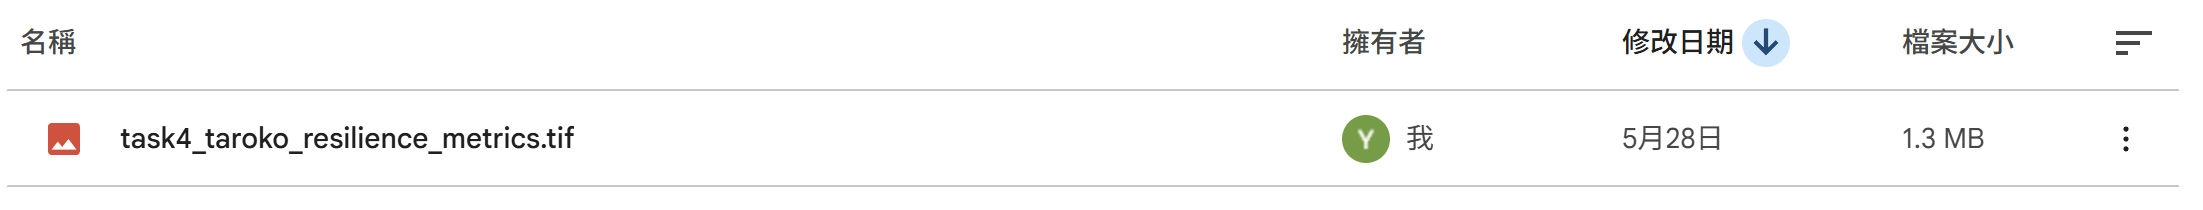

## Bonus 1 — Cell 29：計算 Multi-Index Annual Time Series

本 cell 會開始 Bonus 1：Multi-Index Dashboard。

前面 Task 1 已經建立 `landsat_idx`，其中包含：

- `NDVI`：植被狀態
- `MNDWI`：水體與濕潤程度
- `NBR`：擾動、裸露地或植被破壞訊號

本 cell 會針對 2000–2026 每一年，在太魯閣 AOI 內計算三個指標的年度 median composite 平均值，並輸出成 CSV 到 `output/` 資料夾。

In [63]:
# ============================================================
# Bonus 1 — Cell 29：計算 NDVI / MNDWI / NBR 年度時序
# ============================================================

# ------------------------------------------------------------
# 1. 建立年度多指標統計函數
# ------------------------------------------------------------
def compute_annual_multi_index_stats(year):
    """
    Compute annual area-mean NDVI, MNDWI, and NBR for Taroko AOI.

    Steps:
    1. Filter Landsat indexed collection by year
    2. Create annual median composite
    3. Compute AOI mean for NDVI / MNDWI / NBR
    """
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    yearly_col = landsat_idx.filterDate(start_date, end_date)
    image_count = yearly_col.size().getInfo()

    annual_composite = yearly_col.select(["NDVI", "MNDWI", "NBR"]).median()

    stats = annual_composite.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=8,
        bestEffort=True
    ).getInfo()

    return {
        "year": year,
        "image_count": image_count,
        "NDVI": stats.get("NDVI"),
        "MNDWI": stats.get("MNDWI"),
        "NBR": stats.get("NBR")
    }


# ------------------------------------------------------------
# 2. 逐年計算 2000–2026
# ------------------------------------------------------------
multi_index_results = []

for year in YEARS:
    result = compute_annual_multi_index_stats(year)
    multi_index_results.append(result)

    print(
        f"{year}: "
        f"count={result['image_count']:>3} | "
        f"NDVI={result['NDVI']:.4f} | "
        f"MNDWI={result['MNDWI']:.4f} | "
        f"NBR={result['NBR']:.4f}"
    )


# ------------------------------------------------------------
# 3. 轉成 DataFrame
# ------------------------------------------------------------
multi_index_df = pd.DataFrame(multi_index_results)

display(multi_index_df.head())
display(multi_index_df.tail())


# ------------------------------------------------------------
# 4. 輸出 CSV 到 output 資料夾
# ------------------------------------------------------------
multi_index_csv = OUTPUT_DIR / "bonus1_taroko_multi_index_annual_timeseries.csv"

multi_index_df.to_csv(
    multi_index_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ Multi-index annual time series saved to: {multi_index_csv}")

2000: count= 31 | NDVI=0.5250 | MNDWI=-0.2621 | NBR=0.4946
2001: count= 33 | NDVI=0.5190 | MNDWI=-0.2220 | NBR=0.5167
2002: count= 31 | NDVI=0.5135 | MNDWI=-0.2007 | NBR=0.5188
2003: count= 28 | NDVI=0.5194 | MNDWI=-0.2451 | NBR=0.5036
2004: count= 34 | NDVI=0.5176 | MNDWI=-0.2196 | NBR=0.5260
2005: count= 27 | NDVI=0.4948 | MNDWI=-0.2079 | NBR=0.5043
2006: count= 30 | NDVI=0.5017 | MNDWI=-0.1951 | NBR=0.5086
2007: count= 22 | NDVI=0.4942 | MNDWI=-0.1751 | NBR=0.5277
2008: count= 37 | NDVI=0.5028 | MNDWI=-0.2099 | NBR=0.5059
2009: count= 36 | NDVI=0.5141 | MNDWI=-0.2144 | NBR=0.5182
2010: count= 25 | NDVI=0.5124 | MNDWI=-0.2010 | NBR=0.5238
2011: count= 17 | NDVI=0.5216 | MNDWI=-0.2040 | NBR=0.5098
2012: count= 14 | NDVI=0.5048 | MNDWI=-0.2355 | NBR=0.4849
2013: count= 26 | NDVI=0.5453 | MNDWI=-0.2839 | NBR=0.4564
2014: count= 34 | NDVI=0.5389 | MNDWI=-0.2741 | NBR=0.3403
2015: count= 38 | NDVI=0.5396 | MNDWI=-0.2648 | NBR=0.3912
2016: count= 33 | NDVI=0.5499 | MNDWI=-0.2943 | NBR=0.40

,year,image_count,NDVI,MNDWI,NBR
0,2000,31,0.524979,-0.262122,0.494581
1,2001,33,0.518961,-0.221952,0.516718
2,2002,31,0.513521,-0.200691,0.518848
3,2003,28,0.519373,-0.245120,0.503632
4,2004,34,0.517646,-0.219592,0.525958


,year,image_count,NDVI,MNDWI,NBR
22,2022,54,0.589789,-0.362544,0.284483
23,2023,59,0.567536,-0.318791,0.249324
24,2024,38,0.560317,-0.316481,0.132585
25,2025,33,0.541869,-0.303287,0.131015
26,2026,12,0.581591,-0.337876,0.113726



✅ Multi-index annual time series saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus1_taroko_multi_index_annual_timeseries.csv


## Bonus 1 — Cell 30：建立 Multi-Index Dashboard 圖表

本 cell 會將前一格計算出的：

- NDVI
- MNDWI
- NBR

三種指標年度時序畫成 dashboard 圖表。

圖表目的：

1. 比較三種指標在 26 年中的變化趨勢
2. 觀察 2009 莫拉克颱風與 2024 花蓮地震附近是否出現異常
3. 比較 vegetation / water / burn-disturbance 三種不同環境訊號

圖中將加入：

- 年度折線
- 線性趨勢線
- 2009 Morakot 標示
- 2024 Earthquake 標示

最後輸出 PNG 到 `output/` 資料夾。

✅ Dashboard PNG saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus1_taroko_multi_index_dashboard.png


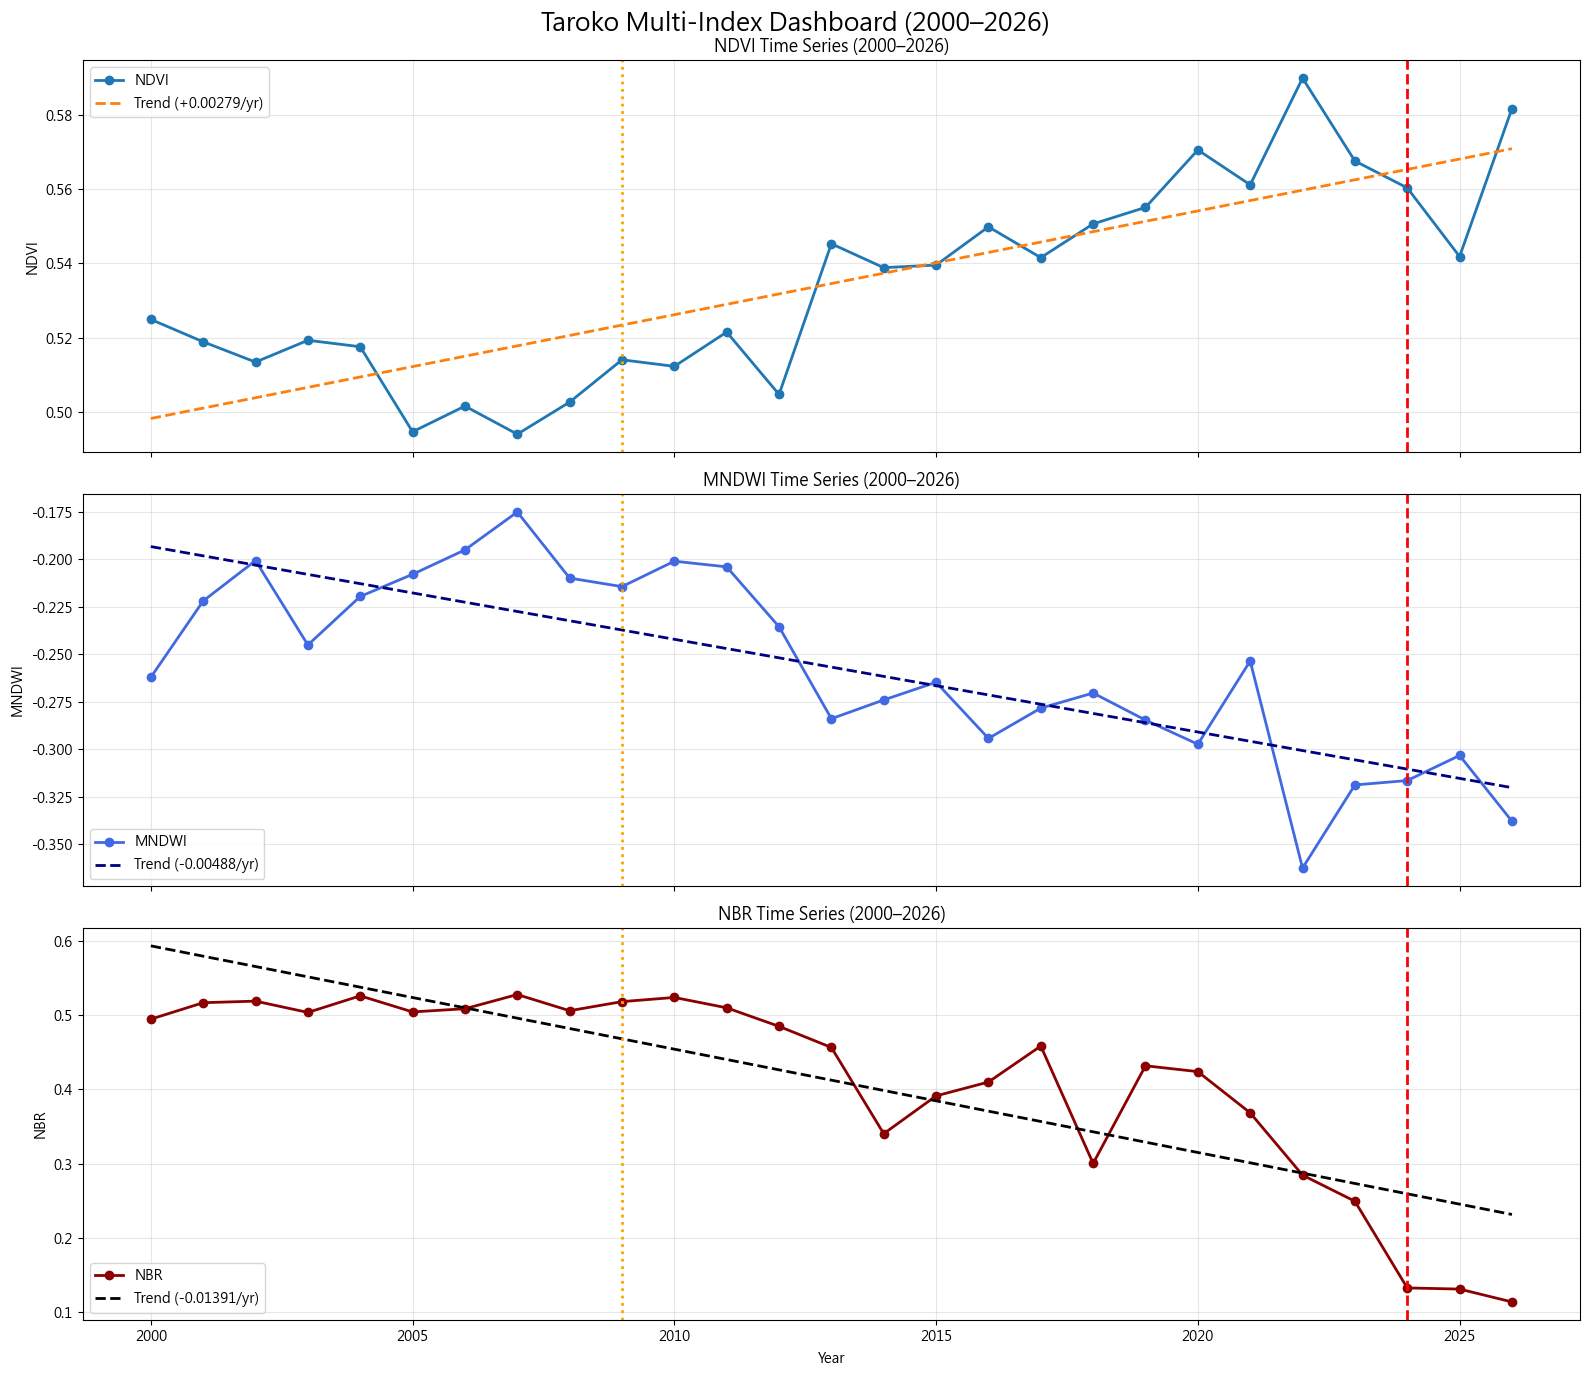

In [64]:
# ============================================================
# Bonus 1 — Cell 30：繪製 Multi-Index Dashboard
# ============================================================

# ------------------------------------------------------------
# 1. 建立 Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 14),
    sharex=True
)

years = multi_index_df["year"]


# ============================================================
# Panel 1 — NDVI
# ============================================================
ax = axes[0]

ax.plot(
    years,
    multi_index_df["NDVI"],
    marker="o",
    linewidth=2,
    label="NDVI"
)

# 線性趨勢
z = np.polyfit(years, multi_index_df["NDVI"], 1)
p = np.poly1d(z)

ax.plot(
    years,
    p(years),
    linestyle="--",
    linewidth=2,
    label=f"Trend ({z[0]:+.5f}/yr)"
)

ax.set_ylabel("NDVI")
ax.set_title("NDVI Time Series (2000–2026)")
ax.grid(True, alpha=0.3)
ax.legend()


# ============================================================
# Panel 2 — MNDWI
# ============================================================
ax = axes[1]

ax.plot(
    years,
    multi_index_df["MNDWI"],
    marker="o",
    linewidth=2,
    color="royalblue",
    label="MNDWI"
)

z = np.polyfit(years, multi_index_df["MNDWI"], 1)
p = np.poly1d(z)

ax.plot(
    years,
    p(years),
    linestyle="--",
    linewidth=2,
    color="navy",
    label=f"Trend ({z[0]:+.5f}/yr)"
)

ax.set_ylabel("MNDWI")
ax.set_title("MNDWI Time Series (2000–2026)")
ax.grid(True, alpha=0.3)
ax.legend()


# ============================================================
# Panel 3 — NBR
# ============================================================
ax = axes[2]

ax.plot(
    years,
    multi_index_df["NBR"],
    marker="o",
    linewidth=2,
    color="darkred",
    label="NBR"
)

z = np.polyfit(years, multi_index_df["NBR"], 1)
p = np.poly1d(z)

ax.plot(
    years,
    p(years),
    linestyle="--",
    linewidth=2,
    color="black",
    label=f"Trend ({z[0]:+.5f}/yr)"
)

ax.set_ylabel("NBR")
ax.set_title("NBR Time Series (2000–2026)")
ax.grid(True, alpha=0.3)
ax.legend()


# ------------------------------------------------------------
# 2. 加入事件年份
# ------------------------------------------------------------
for ax in axes:

    # 2009 Morakot
    ax.axvline(
        2009,
        color="orange",
        linestyle=":",
        linewidth=2
    )

    # 2024 Earthquake
    ax.axvline(
        2024,
        color="red",
        linestyle="--",
        linewidth=2
    )


# ------------------------------------------------------------
# 3. 圖表設定
# ------------------------------------------------------------
axes[-1].set_xlabel("Year")

plt.suptitle(
    "Taroko Multi-Index Dashboard (2000–2026)",
    fontsize=18,
    y=0.98
)

plt.tight_layout()


# ------------------------------------------------------------
# 4. 儲存圖表
# ------------------------------------------------------------
dashboard_png = OUTPUT_DIR / "bonus1_taroko_multi_index_dashboard.png"

plt.savefig(
    dashboard_png,
    dpi=300,
    bbox_inches="tight"
)

print(f"✅ Dashboard PNG saved to: {dashboard_png}")

plt.show()

## Bonus 1 — Cell 31：Multi-Index Dashboard 分析

本 cell 會根據 Bonus 1 的三指標時序結果，自動產生分析文字。

分析重點包括：

1. NDVI 是否呈現長期 greening。
2. MNDWI 是否呈現水分或水體訊號下降。
3. NBR 是否比 NDVI 更敏感地反映擾動。
4. 三種指標是否講述相同或不同的環境變遷故事。
5. 哪個指標最適合用來監測太魯閣山區。

In [65]:
# ============================================================
# Bonus 1 — Cell 31：Multi-Index Dashboard 分析文字
# ============================================================

# ------------------------------------------------------------
# 1. 計算三個指標的線性趨勢
# ------------------------------------------------------------
years_arr = multi_index_df["year"].to_numpy()

ndvi_values = multi_index_df["NDVI"].to_numpy()
mndwi_values = multi_index_df["MNDWI"].to_numpy()
nbr_values = multi_index_df["NBR"].to_numpy()

ndvi_slope, ndvi_intercept = np.polyfit(years_arr, ndvi_values, 1)
mndwi_slope, mndwi_intercept = np.polyfit(years_arr, mndwi_values, 1)
nbr_slope, nbr_intercept = np.polyfit(years_arr, nbr_values, 1)

# ------------------------------------------------------------
# 2. 取得 2009 與 2024 的指標值
# ------------------------------------------------------------
row_2009 = multi_index_df.loc[multi_index_df["year"] == 2009].iloc[0]
row_2024 = multi_index_df.loc[multi_index_df["year"] == 2024].iloc[0]

# ------------------------------------------------------------
# 3. 建立分析文字
# ------------------------------------------------------------
bonus1_analysis_md = f"""
## Bonus 1 — Multi-Index Dashboard Analysis

本 Bonus 使用 Landsat 2000–2026 年資料，同時計算太魯閣研究區的 **NDVI、MNDWI 與 NBR** 三種指標，藉此比較不同光譜指標所呈現的長期環境變化訊號。

### 1. NDVI：植被長期變化

NDVI 的線性趨勢為 **{ndvi_slope:+.5f} / year**，呈現長期上升，表示研究區整體具有 greening 趨勢。這與 Task 1 的 26 年 NDVI 時序結果一致，代表大範圍森林區與自然演替可能抵銷了局部崩塌或災害造成的植被下降。

### 2. MNDWI：水分與水體訊號

MNDWI 的線性趨勢為 **{mndwi_slope:+.5f} / year**，整體呈現下降。由於 MNDWI 在山區環境中不只反映開放水體，也會受到濕潤裸地、陰影、河道與植被含水狀態影響，因此下降趨勢可能代表研究區內水分相關訊號減弱，或河道、裸露地與地表濕潤程度發生變化。

### 3. NBR：擾動與裸露變化訊號

NBR 的線性趨勢為 **{nbr_slope:+.5f} / year**，下降幅度最明顯。相較 NDVI，NBR 使用 NIR 與 SWIR2，對植被受損、裸露地、乾燥化與擾動更敏感。因此，即使 NDVI 顯示整體 greening，NBR 仍可能揭示山區地表擾動逐漸增加，特別是 2024 地震後 NBR 明顯下降，可能反映崩塌、裸露地或坡面破壞增加。

### 4. 事件年份比較

2009 年莫拉克颱風時，NDVI = **{row_2009["NDVI"]:.4f}**，MNDWI = **{row_2009["MNDWI"]:.4f}**，NBR = **{row_2009["NBR"]:.4f}**。2024 年花蓮地震時，NDVI = **{row_2024["NDVI"]:.4f}**，MNDWI = **{row_2024["MNDWI"]:.4f}**，NBR = **{row_2024["NBR"]:.4f}**。從圖表可看出，2024 年的 NDVI 並未劇烈下降，但 NBR 明顯偏低，表示 NBR 可能比 NDVI 更能捕捉災後裸露與擾動訊號。

### 5. 小結

三個指標並沒有完全講述同一個故事。NDVI 強調整體植被狀態，顯示長期 greening；MNDWI 補充水分與水體相關訊號；NBR 則更敏感地揭露擾動與裸露變化。因此，若只用單一指標，可能會忽略部分環境訊號。對太魯閣這類山區災害監測而言，NDVI 適合看植被恢復，NBR 適合看崩塌與地表擾動，MNDWI 則可輔助判讀河道與水文變化。
"""

print(bonus1_analysis_md)

# ------------------------------------------------------------
# 4. 輸出 Markdown 到 output 資料夾
# ------------------------------------------------------------
bonus1_analysis_path = OUTPUT_DIR / "bonus1_multi_index_dashboard_analysis.md"

with open(bonus1_analysis_path, "w", encoding="utf-8") as f:
    f.write(bonus1_analysis_md)

print(f"\n✅ Bonus 1 analysis saved to: {bonus1_analysis_path}")


## Bonus 1 — Multi-Index Dashboard Analysis

本 Bonus 使用 Landsat 2000–2026 年資料，同時計算太魯閣研究區的 **NDVI、MNDWI 與 NBR** 三種指標，藉此比較不同光譜指標所呈現的長期環境變化訊號。

### 1. NDVI：植被長期變化

NDVI 的線性趨勢為 **+0.00279 / year**，呈現長期上升，表示研究區整體具有 greening 趨勢。這與 Task 1 的 26 年 NDVI 時序結果一致，代表大範圍森林區與自然演替可能抵銷了局部崩塌或災害造成的植被下降。

### 2. MNDWI：水分與水體訊號

MNDWI 的線性趨勢為 **-0.00488 / year**，整體呈現下降。由於 MNDWI 在山區環境中不只反映開放水體，也會受到濕潤裸地、陰影、河道與植被含水狀態影響，因此下降趨勢可能代表研究區內水分相關訊號減弱，或河道、裸露地與地表濕潤程度發生變化。

### 3. NBR：擾動與裸露變化訊號

NBR 的線性趨勢為 **-0.01391 / year**，下降幅度最明顯。相較 NDVI，NBR 使用 NIR 與 SWIR2，對植被受損、裸露地、乾燥化與擾動更敏感。因此，即使 NDVI 顯示整體 greening，NBR 仍可能揭示山區地表擾動逐漸增加，特別是 2024 地震後 NBR 明顯下降，可能反映崩塌、裸露地或坡面破壞增加。

### 4. 事件年份比較

2009 年莫拉克颱風時，NDVI = **0.5141**，MNDWI = **-0.2144**，NBR = **0.5182**。2024 年花蓮地震時，NDVI = **0.5603**，MNDWI = **-0.3165**，NBR = **0.1326**。從圖表可看出，2024 年的 NDVI 並未劇烈下降，但 NBR 明顯偏低，表示 NBR 可能比 NDVI 更能捕捉災後裸露與擾動訊號。

### 5. 小結

三個指標並沒有完全講述同一個故事。NDVI 強調整體植被狀態，顯示長期 greening；MNDWI 補充水分與水體相關訊號；NBR 則更敏感地揭露擾動與裸露變化。因此，若只用單一指標，可能會忽略部分環境訊號。對太魯閣這類山區災害監測而言，NDVI 適合看植被恢復，

## Bonus 2 — Cell 32：製作 26 年 NDVI Time-Lapse GIF

本 cell 會製作太魯閣研究區 2000–2026 年的年度 NDVI 動畫 GIF。

流程如下：

1. 逐年建立年度 NDVI median composite。
2. 使用 GEE `getThumbURL()` 取得每一年 NDVI 縮圖。
3. 用 `PIL` 在每張圖上加上年份與事件標記。
4. 用 `imageio` 將 27 張年度影像合成 GIF。
5. 將 GIF 儲存到 `output/` 資料夾。

動畫會標記：

- 2009 Morakot
- 2024 Earthquake

此 GIF 可作為 Bonus 2 的主要成果。

In [66]:
# ============================================================
# Bonus 2 — Cell 32：製作 2000–2026 年 NDVI Time-Lapse GIF
# ============================================================

# ------------------------------------------------------------
# 1. 載入套件
# ------------------------------------------------------------
import io
import requests
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont

# ------------------------------------------------------------
# 2. 設定 GIF 輸出路徑與視覺化參數
# ------------------------------------------------------------
gif_path = OUTPUT_DIR / "bonus2_taroko_ndvi_26yr_timelapse.gif"

ndvi_palette = [
    "8c510a",  # low NDVI / bare
    "d8b365",
    "f6e8c3",
    "c7eae5",
    "5ab4ac",
    "01665e"   # high NDVI / dense vegetation
]

thumb_params_base = {
    "region": aoi,
    "dimensions": 720,
    "min": 0,
    "max": 0.8,
    "palette": ndvi_palette,
    "format": "png"
}

frames = []

# ------------------------------------------------------------
# 3. 嘗試使用系統字型
# ------------------------------------------------------------
# Windows 常見中文字型
font_candidates = [
    "C:/Windows/Fonts/msjh.ttc",   # Microsoft JhengHei
    "C:/Windows/Fonts/arial.ttf"
]

font_path = None
for fp in font_candidates:
    if Path(fp).exists():
        font_path = fp
        break

if font_path:
    title_font = ImageFont.truetype(font_path, 28)
    small_font = ImageFont.truetype(font_path, 20)
else:
    title_font = ImageFont.load_default()
    small_font = ImageFont.load_default()

print("Font used:", font_path if font_path else "PIL default font")

# ------------------------------------------------------------
# 4. 逐年產生 NDVI frame
# ------------------------------------------------------------
for year in YEARS:

    print(f"Processing {year}...")

    annual_ndvi_frame = (
        ndvi_collection
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .median()
        .clip(aoi)
    )

    thumb_url = annual_ndvi_frame.getThumbURL(thumb_params_base)

    response = requests.get(thumb_url)
    response.raise_for_status()

    img = Image.open(io.BytesIO(response.content)).convert("RGB")

    # --------------------------------------------------------
    # 加入文字標籤
    # --------------------------------------------------------
    draw = ImageDraw.Draw(img)

    label = f"Taroko NDVI — {year}"

    event_label = ""
    if year == 2009:
        event_label = "Typhoon Morakot"
    elif year == 2024:
        event_label = "2024 Hualien Earthquake"

    # 背景框
    draw.rectangle(
        [(10, 10), (470, 95)],
        fill=(0, 0, 0)
    )

    draw.text(
        (25, 22),
        label,
        fill=(255, 255, 255),
        font=title_font
    )

    if event_label:
        draw.text(
            (25, 60),
            event_label,
            fill=(255, 220, 0),
            font=small_font
        )
    else:
        draw.text(
            (25, 60),
            "Annual median NDVI",
            fill=(220, 220, 220),
            font=small_font
        )

    frames.append(np.array(img))

print(f"Total frames: {len(frames)}")

# ------------------------------------------------------------
# 5. 輸出 GIF
# ------------------------------------------------------------
imageio.mimsave(
    gif_path,
    frames,
    duration=0.75,
    loop=0
)

print(f"\n✅ NDVI time-lapse GIF saved to: {gif_path}")

Font used: C:/Windows/Fonts/msjh.ttc
Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...
Processing 2026...
Total frames: 27

✅ NDVI time-lapse GIF saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus2_taroko_ndvi_26yr_timelapse.gif


## Bonus 2 — Cell 33：NDVI Time-Lapse Animation Description

本 cell 會根據 2000–2026 年 NDVI GIF 動畫，產生 50–100 字的觀察說明。

說明內容會聚焦於：

1. 長期植被變化趨勢。
2. 2009 莫拉克颱風附近是否有明顯變化。
3. 2024 花蓮地震後是否出現局部退化或恢復。

In [67]:
# ============================================================
# Bonus 2 — Cell 33：NDVI Time-Lapse Animation Description
# ============================================================

bonus2_description_md = """
## Bonus 2 — NDVI Time-Lapse Animation Description

The 26-year NDVI time-lapse shows that Taroko remains largely forested over the long term, but localized disturbance signals appear along valleys, slopes, and coastal mountain areas. Around **2009**, after Typhoon Morakot, some areas show reduced vegetation continuity, although the regional forest background remains stable. The most visible change occurs after the **2024 Hualien Earthquake**, when localized low-NDVI patches and disturbed slopes become more apparent. By **2025–2026**, some areas show signs of recovery, but several disturbed zones remain visible, suggesting uneven post-earthquake resilience.

## 中文說明

26 年 NDVI 動畫顯示，太魯閣研究區整體長期仍以森林覆蓋為主，但河谷、坡面與海岸山麓附近可觀察到局部擾動。**2009 年莫拉克颱風**後，部分區域的植被連續性略有下降，但整體森林背景仍相對穩定。較明顯的變化出現在 **2024 年花蓮地震**後，局部低 NDVI 斑塊與受擾坡面變得更清楚。到了 **2025–2026 年**，部分地區可見恢復跡象，但仍有若干受擾區持續存在，顯示震後恢復具有空間差異。
"""

print(bonus2_description_md)

# ------------------------------------------------------------
# 輸出 Markdown 到 output 資料夾
# ------------------------------------------------------------
bonus2_description_path = OUTPUT_DIR / "bonus2_ndvi_timelapse_description.md"

with open(bonus2_description_path, "w", encoding="utf-8") as f:
    f.write(bonus2_description_md)

print(f"\n✅ Bonus 2 description saved to: {bonus2_description_path}")


## Bonus 2 — NDVI Time-Lapse Animation Description

The 26-year NDVI time-lapse shows that Taroko remains largely forested over the long term, but localized disturbance signals appear along valleys, slopes, and coastal mountain areas. Around **2009**, after Typhoon Morakot, some areas show reduced vegetation continuity, although the regional forest background remains stable. The most visible change occurs after the **2024 Hualien Earthquake**, when localized low-NDVI patches and disturbed slopes become more apparent. By **2025–2026**, some areas show signs of recovery, but several disturbed zones remain visible, suggesting uneven post-earthquake resilience.

## 中文說明

26 年 NDVI 動畫顯示，太魯閣研究區整體長期仍以森林覆蓋為主，但河谷、坡面與海岸山麓附近可觀察到局部擾動。**2009 年莫拉克颱風**後，部分區域的植被連續性略有下降，但整體森林背景仍相對穩定。較明顯的變化出現在 **2024 年花蓮地震**後，局部低 NDVI 斑塊與受擾坡面變得更清楚。到了 **2025–2026 年**，部分地區可見恢復跡象，但仍有若干受擾區持續存在，顯示震後恢復具有空間差異。


✅ Bonus 2 description saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\b

## Bonus 3 — Cell 34：載入 Sentinel-2 並建立 NDVI Collection

本 cell 會開始 Bonus 3：Landsat × Sentinel-2 跨感測器分析。

目的：

1. 載入 Sentinel-2 Surface Reflectance Harmonized 資料。
2. 使用 SCL band 做雲、雲影與雪遮罩。
3. 計算 Sentinel-2 NDVI。
4. 建立 2018–2026 年 Sentinel-2 NDVI collection。

後續會將 Sentinel-2 的年度平均 NDVI 與 Landsat 年度平均 NDVI 比較，分析不同解析度與不同感測器造成的差異。

In [68]:
# ============================================================
# Bonus 3 — Cell 34：載入 Sentinel-2 並建立 NDVI Collection
# ============================================================

# ------------------------------------------------------------
# 1. Sentinel-2 雲遮罩與 NDVI 函數
# ------------------------------------------------------------
def mask_s2_sr(image):
    """
    Mask Sentinel-2 SR image using SCL band.

    SCL classes retained:
    4 = Vegetation
    5 = Not vegetated
    6 = Water
    7 = Unclassified

    Masked classes:
    3 = Cloud shadow
    8 = Medium probability cloud
    9 = High probability cloud
    10 = Thin cirrus
    11 = Snow / ice
    """
    scl = image.select("SCL")

    clear_mask = (
        scl.eq(4)
        .Or(scl.eq(5))
        .Or(scl.eq(6))
        .Or(scl.eq(7))
    )

    return (
        image
        .updateMask(clear_mask)
        .copyProperties(image, ["system:time_start"])
    )


def add_s2_ndvi(image):
    """
    Add Sentinel-2 NDVI band.

    Sentinel-2:
    B4 = Red
    B8 = NIR
    """
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")

    return (
        image
        .addBands(ndvi)
        .copyProperties(image, ["system:time_start"])
    )


# ------------------------------------------------------------
# 2. 載入 Sentinel-2 SR Harmonized
# ------------------------------------------------------------
# Sentinel-2 L2A 在 GEE 中較完整的期間通常從 2017 / 2018 後較穩定。
# 這裡使用 2018–2026 進行跨感測器比較。

s2_sr = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2018-01-01", "2026-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 70))
    .map(mask_s2_sr)
    .map(add_s2_ndvi)
)

s2_ndvi_collection = s2_sr.select("NDVI")

# ------------------------------------------------------------
# 3. 檢查 Sentinel-2 影像數量
# ------------------------------------------------------------
s2_count = s2_ndvi_collection.size().getInfo()

print("Sentinel-2 NDVI collection ready.")
print(f"Sentinel-2 image count: {s2_count}")
print("Bands:", s2_ndvi_collection.first().bandNames().getInfo())

# ------------------------------------------------------------
# 4. 顯示一張 Sentinel-2 NDVI 檢查圖
# ------------------------------------------------------------
s2_check = (
    s2_ndvi_collection
    .filterDate("2024-01-01", "2024-12-31")
    .median()
    .clip(aoi)
)

Map_s2_check = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_s2_check.add_basemap("OpenStreetMap")

Map_s2_check.addLayer(
    s2_check,
    {
        "min": 0,
        "max": 0.8,
        "palette": ["brown", "yellow", "lightgreen", "darkgreen"]
    },
    "Sentinel-2 NDVI 2024"
)

Map_s2_check.addLayer(
    aoi,
    {"color": "red"},
    "Taroko AOI"
)

Map_s2_check.addLayerControl()

Map_s2_check

Sentinel-2 NDVI collection ready.
Sentinel-2 image count: 615
Bands: ['NDVI']


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Bonus 3 — Cell 35：Cross-Sensor Annual NDVI Comparison

本 cell 會計算 Landsat 與 Sentinel-2 在重疊年份中的年度平均 NDVI。

比較年份設定為 2018–2026，原因是 Sentinel-2 L2A 在 GEE 中從 2018 年後資料較穩定。

本 cell 會輸出：

1. Landsat 年均 NDVI
2. Sentinel-2 年均 NDVI
3. 兩者差值 `S2 - Landsat`
4. 每年可用影像數量

這份表格會作為下一格 cross-sensor scatter plot 與 R² 分析的基礎。

In [70]:
# ============================================================
# Bonus 3 — Cell 35：計算 Landsat vs Sentinel-2 年均 NDVI
# ============================================================

# ------------------------------------------------------------
# 1. 設定跨感測器比較年份
# ------------------------------------------------------------
CROSS_SENSOR_START_YEAR = 2018
CROSS_SENSOR_END_YEAR = 2026

cross_years = list(range(CROSS_SENSOR_START_YEAR, CROSS_SENSOR_END_YEAR + 1))

print("Cross-sensor comparison years:", cross_years)

# ------------------------------------------------------------
# 2. 建立單一年份統計函數
# ------------------------------------------------------------
def compute_cross_sensor_year_stats(year):
    """
    Compute annual mean NDVI for Landsat and Sentinel-2 in the same AOI.

    Landsat:
    - 30 m
    - annual median NDVI

    Sentinel-2:
    - 10 m
    - annual median NDVI
    """
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    # Landsat annual NDVI
    landsat_year_col = ndvi_collection.filterDate(start_date, end_date)
    landsat_count = landsat_year_col.size().getInfo()

    landsat_annual_ndvi = (
        landsat_year_col
        .median()
        .rename("landsat_ndvi")
        .clip(aoi)
    )

    landsat_stats = landsat_annual_ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=8,
        bestEffort=True
    ).getInfo()

    landsat_mean = landsat_stats.get("landsat_ndvi")

    # Sentinel-2 annual NDVI
    s2_year_col = s2_ndvi_collection.filterDate(start_date, end_date)
    s2_count = s2_year_col.size().getInfo()

    s2_annual_ndvi = (
        s2_year_col
        .median()
        .rename("s2_ndvi")
        .clip(aoi)
    )

    s2_stats = s2_annual_ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9,
        tileScale=8,
        bestEffort=True
    ).getInfo()

    s2_mean = s2_stats.get("s2_ndvi")

    return {
        "year": year,
        "landsat_count": landsat_count,
        "s2_count": s2_count,
        "landsat_ndvi": landsat_mean,
        "s2_ndvi": s2_mean,
        "s2_minus_landsat": None if landsat_mean is None or s2_mean is None else s2_mean - landsat_mean
    }


# ------------------------------------------------------------
# 3. 逐年計算
# ------------------------------------------------------------
cross_sensor_results = []

for year in cross_years:
    result = compute_cross_sensor_year_stats(year)
    cross_sensor_results.append(result)

    print(
        f"{year}: "
        f"Landsat={result['landsat_ndvi']:.4f} "
        f"(n={result['landsat_count']}) | "
        f"S2={result['s2_ndvi']:.4f} "
        f"(n={result['s2_count']}) | "
        f"S2-Landsat={result['s2_minus_landsat']:+.4f}"
    )


# ------------------------------------------------------------
# 4. 建立 DataFrame
# ------------------------------------------------------------
cross_sensor_df = pd.DataFrame(cross_sensor_results)

display(cross_sensor_df)

# ------------------------------------------------------------
# 5. 輸出 CSV
# ------------------------------------------------------------
cross_sensor_csv = OUTPUT_DIR / "bonus3_landsat_sentinel2_annual_ndvi_comparison.csv"

cross_sensor_df.to_csv(
    cross_sensor_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ Cross-sensor annual NDVI comparison saved to: {cross_sensor_csv}")

Cross-sensor comparison years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
2018: Landsat=0.5506 (n=37) | S2=0.4945 (n=4) | S2-Landsat=-0.0562
2019: Landsat=0.5551 (n=35) | S2=0.5030 (n=83) | S2-Landsat=-0.0521
2020: Landsat=0.5705 (n=39) | S2=0.5099 (n=91) | S2-Landsat=-0.0606
2021: Landsat=0.5611 (n=43) | S2=0.4954 (n=99) | S2-Landsat=-0.0657
2022: Landsat=0.5898 (n=54) | S2=0.5285 (n=66) | S2-Landsat=-0.0613
2023: Landsat=0.5675 (n=59) | S2=0.5167 (n=66) | S2-Landsat=-0.0508
2024: Landsat=0.5603 (n=38) | S2=0.5021 (n=85) | S2-Landsat=-0.0582
2025: Landsat=0.5419 (n=33) | S2=0.5100 (n=86) | S2-Landsat=-0.0318
2026: Landsat=0.5816 (n=12) | S2=0.4939 (n=34) | S2-Landsat=-0.0877


,year,landsat_count,s2_count,landsat_ndvi,s2_ndvi,s2_minus_landsat
0,2018,37,4,0.550636,0.494486,-0.056151
1,2019,35,83,0.555073,0.502951,-0.052122
2,2020,39,91,0.570498,0.509910,-0.060589
3,2021,43,99,0.561140,0.495434,-0.065706
4,2022,54,66,0.589789,0.528462,-0.061327
5,2023,59,66,0.567536,0.516693,-0.050843
6,2024,38,85,0.560317,0.502127,-0.058189
7,2025,33,86,0.541869,0.510038,-0.031831
8,2026,12,34,0.581591,0.493937,-0.087654



✅ Cross-sensor annual NDVI comparison saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus3_landsat_sentinel2_annual_ndvi_comparison.csv


## Bonus 3 — Cell 36：Cross-Sensor Scatter Plot 與 R²

本 cell 會使用上一格建立的 `cross_sensor_df`，比較 Landsat 與 Sentinel-2 的年度平均 NDVI。

分析內容包含：

1. 繪製 Landsat NDVI vs Sentinel-2 NDVI 散點圖。
2. 加入線性迴歸線。
3. 計算 R²，評估兩個感測器年度 NDVI 的一致性。
4. 輸出 PNG 圖表到 `output/` 資料夾。

若 R² 較高，代表兩個感測器的年度變化趨勢一致；若 R² 較低，可能代表解析度、雲遮罩、觀測日期、波段響應或混合像素效應造成差異。

Cross-sensor regression:
  S2_NDVI = 0.3150 × Landsat_NDVI + 0.3283
  R² = 0.1676


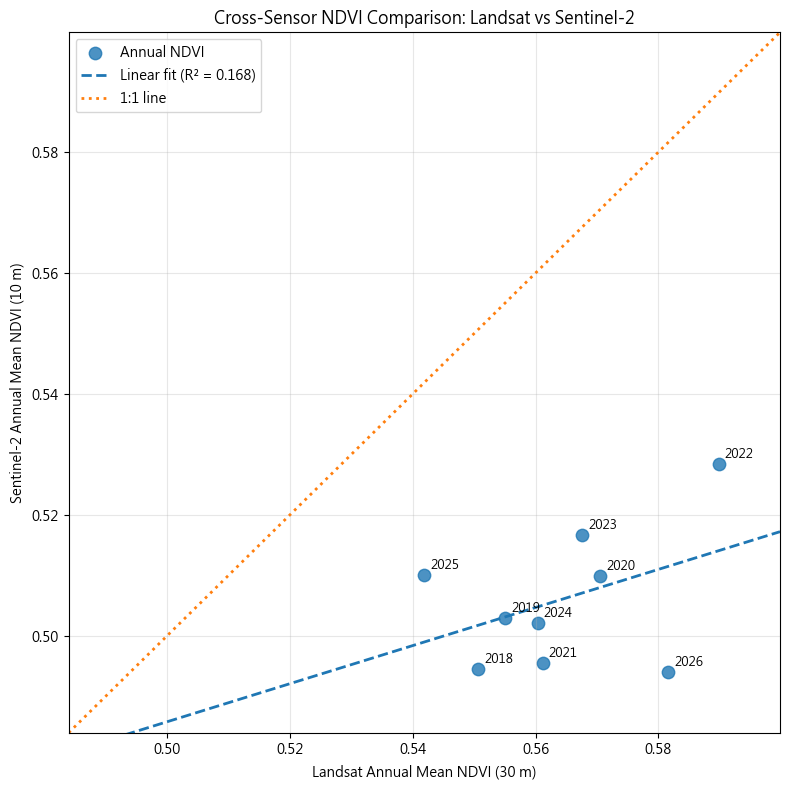

✅ Cross-sensor scatter plot saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus3_landsat_vs_sentinel2_ndvi_scatter.png


In [72]:
# ============================================================
# Bonus 3 — Cell 36：Landsat vs Sentinel-2 Scatter Plot + R²
# ============================================================

from sklearn.metrics import r2_score

# ------------------------------------------------------------
# 1. 清理資料
# ------------------------------------------------------------
cross_sensor_clean = cross_sensor_df.dropna(
    subset=["landsat_ndvi", "s2_ndvi"]
).copy()

x = cross_sensor_clean["landsat_ndvi"].to_numpy()
y = cross_sensor_clean["s2_ndvi"].to_numpy()

# ------------------------------------------------------------
# 2. 線性回歸與 R²
# ------------------------------------------------------------
coef = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coef)

y_pred = fit_fn(x)
r2 = r2_score(y, y_pred)

print("Cross-sensor regression:")
print(f"  S2_NDVI = {coef[0]:.4f} × Landsat_NDVI + {coef[1]:.4f}")
print(f"  R² = {r2:.4f}")

# ------------------------------------------------------------
# 3. 繪製散點圖
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    x,
    y,
    s=80,
    alpha=0.8,
    label="Annual NDVI"
)

# 加上年份標籤
for _, row in cross_sensor_clean.iterrows():
    ax.text(
        row["landsat_ndvi"] + 0.001,
        row["s2_ndvi"] + 0.001,
        str(int(row["year"])),
        fontsize=9
    )

# ------------------------------------------------------------
# 設定完整圖表範圍
# ------------------------------------------------------------
axis_min = min(x.min(), y.min()) - 0.01
axis_max = max(x.max(), y.max()) + 0.01

ax.set_xlim(axis_min, axis_max)
ax.set_ylim(axis_min, axis_max)

# 用完整 x 軸範圍延伸 regression line
x_line = np.linspace(axis_min, axis_max, 100)

ax.plot(
    x_line,
    fit_fn(x_line),
    linestyle="--",
    linewidth=2,
    label=f"Linear fit (R² = {r2:.3f})"
)

# 1:1 reference line
ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle=":",
    linewidth=2,
    label="1:1 line"
)

ax.set_xlabel("Landsat Annual Mean NDVI (30 m)")
ax.set_ylabel("Sentinel-2 Annual Mean NDVI (10 m)")
ax.set_title("Cross-Sensor NDVI Comparison: Landsat vs Sentinel-2")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# 4. 儲存圖表
# ------------------------------------------------------------
scatter_png = OUTPUT_DIR / "bonus3_landsat_vs_sentinel2_ndvi_scatter.png"

plt.savefig(
    scatter_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Cross-sensor scatter plot saved to: {scatter_png}")

## Bonus 3 — Cell 37：Cross-Sensor Time Series 與 Bias Analysis

本 cell 會接續上一格的 scatter plot，進一步比較 Landsat 與 Sentinel-2 在 2018–2026 年的年度 NDVI 時序。

本 cell 會產生兩張圖：

1. **Landsat vs Sentinel-2 NDVI Time Series**  
   比較兩個感測器是否呈現相似的年度變化方向。

2. **Bias Plot：S2 − Landsat**  
   顯示 Sentinel-2 NDVI 與 Landsat NDVI 的差異。  
   若 bias 長期為負值，代表 Sentinel-2 年均 NDVI 系統性低於 Landsat。

這張圖比 scatter plot 更適合說明跨感測器在時間趨勢上的一致性與偏差。

Cross-sensor bias summary:
  Mean bias (S2 - Landsat): -0.0583
  Std. bias              : 0.0139
  Min bias               : -0.0877
  Max bias               : -0.0318


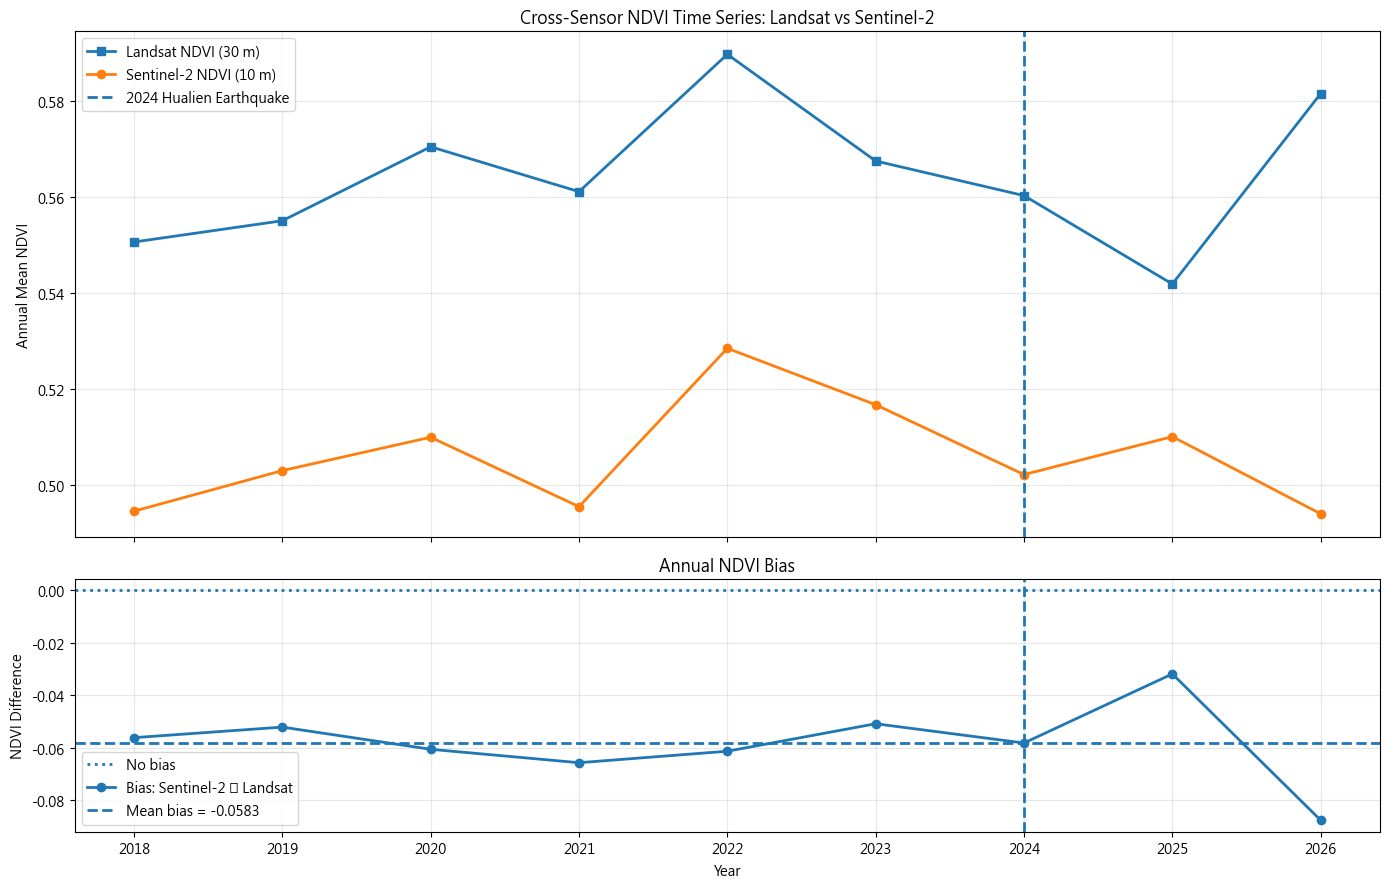

✅ Cross-sensor time series and bias plot saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus3_cross_sensor_ndvi_timeseries_bias.png


In [73]:
# ============================================================
# Bonus 3 — Cell 37：Cross-Sensor Time Series + Bias Plot
# ============================================================

# ------------------------------------------------------------
# 1. 準備資料
# ------------------------------------------------------------
cross_sensor_clean = cross_sensor_df.dropna(
    subset=["landsat_ndvi", "s2_ndvi", "s2_minus_landsat"]
).copy()

years_cs = cross_sensor_clean["year"].to_numpy()
landsat_ndvi_cs = cross_sensor_clean["landsat_ndvi"].to_numpy()
s2_ndvi_cs = cross_sensor_clean["s2_ndvi"].to_numpy()
bias_cs = cross_sensor_clean["s2_minus_landsat"].to_numpy()

mean_bias = bias_cs.mean()
std_bias = bias_cs.std()

print("Cross-sensor bias summary:")
print(f"  Mean bias (S2 - Landsat): {mean_bias:+.4f}")
print(f"  Std. bias              : {std_bias:.4f}")
print(f"  Min bias               : {bias_cs.min():+.4f}")
print(f"  Max bias               : {bias_cs.max():+.4f}")

# ------------------------------------------------------------
# 2. 建立圖表：上圖為 NDVI 時序，下圖為 bias
# ------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# ------------------------------------------------------------
# Panel 1：Landsat vs Sentinel-2 NDVI time series
# ------------------------------------------------------------
ax = axes[0]

ax.plot(
    years_cs,
    landsat_ndvi_cs,
    marker="s",
    linewidth=2,
    label="Landsat NDVI (30 m)"
)

ax.plot(
    years_cs,
    s2_ndvi_cs,
    marker="o",
    linewidth=2,
    label="Sentinel-2 NDVI (10 m)"
)

ax.axvline(
    2024,
    linestyle="--",
    linewidth=2,
    label="2024 Hualien Earthquake"
)

ax.set_ylabel("Annual Mean NDVI")
ax.set_title("Cross-Sensor NDVI Time Series: Landsat vs Sentinel-2")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# Panel 2：Bias plot
# ------------------------------------------------------------
ax = axes[1]

ax.axhline(
    0,
    linestyle=":",
    linewidth=2,
    label="No bias"
)

ax.plot(
    years_cs,
    bias_cs,
    marker="o",
    linewidth=2,
    label="Bias: Sentinel-2 − Landsat"
)

ax.axhline(
    mean_bias,
    linestyle="--",
    linewidth=2,
    label=f"Mean bias = {mean_bias:+.4f}"
)

ax.axvline(
    2024,
    linestyle="--",
    linewidth=2
)

ax.set_xlabel("Year")
ax.set_ylabel("NDVI Difference")
ax.set_title("Annual NDVI Bias")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# 3. 儲存圖表
# ------------------------------------------------------------
timeseries_bias_png = OUTPUT_DIR / "bonus3_cross_sensor_ndvi_timeseries_bias.png"

plt.savefig(
    timeseries_bias_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Cross-sensor time series and bias plot saved to: {timeseries_bias_png}")

## Bonus 3 — Cell 38：Multi-Resolution Earthquake ΔNDVI Comparison

本 cell 會使用 Landsat 30 m 與 Sentinel-2 10 m 分別計算 2024 花蓮地震前後的 NDVI 變化。

比較時期設定為：

1. **Pre-earthquake period**：2023-01-01 至 2024-03-31  
2. **Post-earthquake period**：2024-04-01 至 2024-12-31  

計算方式：

`ΔNDVI = Post NDVI - Pre NDVI`

判讀方式：

- `ΔNDVI < -0.15`：可能為明顯植被受損區
- Landsat 30 m：適合看整體受損趨勢
- Sentinel-2 10 m：適合看較細緻的崩塌面與道路邊坡變化

In [76]:
# ============================================================
# Bonus 3 — Cell 38 修正版：Landsat vs Sentinel-2 ΔNDVI Damage Comparison
# ============================================================

# ------------------------------------------------------------
# 1. 設定地震前後時間
# ------------------------------------------------------------
PRE_START = "2023-01-01"
PRE_END   = "2024-03-31"

POST_START = "2024-04-01"
POST_END   = "2024-12-31"

DNDVI_DAMAGE_TH = -0.15

print("Earthquake ΔNDVI comparison periods:")
print(f"  Pre-earthquake : {PRE_START} to {PRE_END}")
print(f"  Post-earthquake: {POST_START} to {POST_END}")
print(f"  Damage threshold: ΔNDVI < {DNDVI_DAMAGE_TH}")

# ------------------------------------------------------------
# 2. Landsat 30 m ΔNDVI
# ------------------------------------------------------------
landsat_pre_ndvi = (
    ndvi_collection
    .filterDate(PRE_START, PRE_END)
    .median()
    .rename("landsat_pre_ndvi")
    .clip(aoi)
)

landsat_post_ndvi = (
    ndvi_collection
    .filterDate(POST_START, POST_END)
    .median()
    .rename("landsat_post_ndvi")
    .clip(aoi)
)

landsat_dndvi = (
    landsat_post_ndvi
    .subtract(landsat_pre_ndvi)
    .rename("landsat_dndvi")
    .clip(aoi)
)

landsat_damage_binary = (
    landsat_dndvi
    .lt(DNDVI_DAMAGE_TH)
    .unmask(0)
    .toByte()
    .rename("landsat_damage")
    .clip(aoi)
)

landsat_damage_display = landsat_damage_binary.updateMask(
    landsat_damage_binary.eq(1)
)

# ------------------------------------------------------------
# 3. Sentinel-2 10 m ΔNDVI
# ------------------------------------------------------------
s2_pre_ndvi = (
    s2_ndvi_collection
    .filterDate(PRE_START, PRE_END)
    .median()
    .rename("s2_pre_ndvi")
    .clip(aoi)
)

s2_post_ndvi = (
    s2_ndvi_collection
    .filterDate(POST_START, POST_END)
    .median()
    .rename("s2_post_ndvi")
    .clip(aoi)
)

s2_dndvi = (
    s2_post_ndvi
    .subtract(s2_pre_ndvi)
    .rename("s2_dndvi")
    .clip(aoi)
)

s2_damage_binary = (
    s2_dndvi
    .lt(DNDVI_DAMAGE_TH)
    .unmask(0)
    .toByte()
    .rename("s2_damage")
    .clip(aoi)
)

s2_damage_display = s2_damage_binary.updateMask(
    s2_damage_binary.eq(1)
)

# ------------------------------------------------------------
# 4. 檢查影像數量
# ------------------------------------------------------------
landsat_pre_count = ndvi_collection.filterDate(PRE_START, PRE_END).size().getInfo()
landsat_post_count = ndvi_collection.filterDate(POST_START, POST_END).size().getInfo()

s2_pre_count = s2_ndvi_collection.filterDate(PRE_START, PRE_END).size().getInfo()
s2_post_count = s2_ndvi_collection.filterDate(POST_START, POST_END).size().getInfo()

print("\nImage count:")
print(f"  Landsat pre : {landsat_pre_count}")
print(f"  Landsat post: {landsat_post_count}")
print(f"  S2 pre      : {s2_pre_count}")
print(f"  S2 post     : {s2_post_count}")

# ------------------------------------------------------------
# 5. 檢查 ΔNDVI 統計值
# ------------------------------------------------------------
dndvi_stack = (
    landsat_dndvi
    .addBands(s2_dndvi)
)

dndvi_stats = dndvi_stack.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
        .combine(reducer2=ee.Reducer.max(), sharedInputs=True),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=8,
    bestEffort=True
).getInfo()

print("\nΔNDVI statistics:")
print(f"  Landsat mean: {dndvi_stats.get('landsat_dndvi_mean'):.4f}")
print(f"  Landsat min : {dndvi_stats.get('landsat_dndvi_min'):.4f}")
print(f"  Landsat max : {dndvi_stats.get('landsat_dndvi_max'):.4f}")
print(f"  S2 mean     : {dndvi_stats.get('s2_dndvi_mean'):.4f}")
print(f"  S2 min      : {dndvi_stats.get('s2_dndvi_min'):.4f}")
print(f"  S2 max      : {dndvi_stats.get('s2_dndvi_max'):.4f}")

# ------------------------------------------------------------
# 6. 檢查受損面積
# ------------------------------------------------------------
damage_area_img = (
    landsat_damage_binary.eq(1).multiply(ee.Image.pixelArea()).rename("landsat_damage_area")
    .addBands(
        s2_damage_binary.eq(1).multiply(ee.Image.pixelArea()).rename("s2_damage_area")
    )
)

damage_area_stats = damage_area_img.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=8,
    bestEffort=True
).getInfo()

landsat_damage_km2 = damage_area_stats.get("landsat_damage_area", 0) / 1e6
s2_damage_km2 = damage_area_stats.get("s2_damage_area", 0) / 1e6

print("\nDamage area:")
print(f"  Landsat damage area: {landsat_damage_km2:.3f} km²")
print(f"  S2 damage area     : {s2_damage_km2:.3f} km²")

# ------------------------------------------------------------
# 7. 視覺化參數
# ------------------------------------------------------------
dndvi_vis = {
    "min": -0.4,
    "max": 0.2,
    "palette": [
        "a50026",
        "d73027",
        "f46d43",
        "fdae61",
        "ffffbf",
        "a6d96a",
        "1a9850"
    ]
}

# ------------------------------------------------------------
# 8. 建立互動地圖
# ------------------------------------------------------------
Map_dndvi_compare = geemap.Map(center=[24.20, 121.60], zoom=10)
Map_dndvi_compare.add_basemap("OpenStreetMap")

# Landsat ΔNDVI
Map_dndvi_compare.addLayer(
    landsat_dndvi,
    dndvi_vis,
    "Landsat ΔNDVI 30 m",
    shown=True
)

# Sentinel-2 ΔNDVI
Map_dndvi_compare.addLayer(
    s2_dndvi,
    dndvi_vis,
    "Sentinel-2 ΔNDVI 10 m",
    shown=True
)

'''# Landsat damage mask：紅色
Map_dndvi_compare.addLayer(
    landsat_damage_display,
    {
        "min": 1,
        "max": 1,
        "palette": ["ff0000"],
        "opacity": 0.9
    },
    "Landsat damage ΔNDVI < -0.15",
    shown=False
)

# S2 damage mask：藍色
Map_dndvi_compare.addLayer(
    s2_damage_display,
    {
        "min": 1,
        "max": 1,
        "palette": ["0000ff"],
        "opacity": 0.9
    },
    "S2 damage ΔNDVI < -0.15",
    shown=False
)'''

Map_dndvi_compare.addLayer(
    aoi,
    {"color": "black"},
    "Taroko AOI"
)

Map_dndvi_compare.addLayerControl()

# ------------------------------------------------------------
# 9. 輸出 HTML
# ------------------------------------------------------------
bonus3_dndvi_html = OUTPUT_DIR / "bonus3_landsat_s2_dndvi_damage_comparison.html"

Map_dndvi_compare.to_html(str(bonus3_dndvi_html))

print(f"\n✅ ΔNDVI comparison map saved to: {bonus3_dndvi_html}")

Map_dndvi_compare

Earthquake ΔNDVI comparison periods:
  Pre-earthquake : 2023-01-01 to 2024-03-31
  Post-earthquake: 2024-04-01 to 2024-12-31
  Damage threshold: ΔNDVI < -0.15

Image count:
  Landsat pre : 70
  Landsat post: 27
  S2 pre      : 88
  S2 post     : 65

ΔNDVI statistics:
  Landsat mean: 0.0268
  Landsat min : -1.2006
  Landsat max : 1.0000
  S2 mean     : -0.0062
  S2 min      : -0.9432
  S2 max      : 0.9737

Damage area:
  Landsat damage area: 70.068 km²
  S2 damage area     : 78.519 km²

✅ ΔNDVI comparison map saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus3_landsat_s2_dndvi_damage_comparison.html


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Bonus 3 — Cell 39：多解析度受損面積比較表

本 cell 會整理 Landsat 30 m 與 Sentinel-2 10 m 的地震後受損面積比較。

受損定義為：

`ΔNDVI < -0.15`

比較重點：

1. Landsat 30 m 偵測到的受損面積。
2. Sentinel-2 10 m 偵測到的受損面積。
3. 兩者面積差異。
4. Sentinel-2 相對 Landsat 多偵測多少比例。

這份表格可作為 Bonus 3 的 multi-resolution damage area comparison table。

In [77]:
# ============================================================
# Bonus 3 — Cell 39：Damage Area Comparison Table
# ============================================================

# ------------------------------------------------------------
# 1. 整理前一格計算出的受損面積
# ------------------------------------------------------------
area_difference_km2 = s2_damage_km2 - landsat_damage_km2
area_difference_pct = area_difference_km2 / landsat_damage_km2 * 100

damage_area_compare_df = pd.DataFrame([
    {
        "sensor": "Landsat",
        "resolution_m": 30,
        "damage_definition": f"ΔNDVI < {DNDVI_DAMAGE_TH}",
        "damage_area_km2": landsat_damage_km2,
        "relative_to_landsat_pct": 100.0
    },
    {
        "sensor": "Sentinel-2",
        "resolution_m": 10,
        "damage_definition": f"ΔNDVI < {DNDVI_DAMAGE_TH}",
        "damage_area_km2": s2_damage_km2,
        "relative_to_landsat_pct": s2_damage_km2 / landsat_damage_km2 * 100
    },
    {
        "sensor": "Difference: S2 - Landsat",
        "resolution_m": None,
        "damage_definition": f"ΔNDVI < {DNDVI_DAMAGE_TH}",
        "damage_area_km2": area_difference_km2,
        "relative_to_landsat_pct": area_difference_pct
    }
])

display(damage_area_compare_df)

print("Multi-resolution damage area comparison:")
print(f"  Landsat damage area : {landsat_damage_km2:.3f} km²")
print(f"  S2 damage area      : {s2_damage_km2:.3f} km²")
print(f"  Difference          : {area_difference_km2:+.3f} km²")
print(f"  Difference percent  : {area_difference_pct:+.2f}%")

# ------------------------------------------------------------
# 2. 輸出 CSV
# ------------------------------------------------------------
damage_area_compare_csv = OUTPUT_DIR / "bonus3_multiresolution_damage_area_comparison.csv"

damage_area_compare_df.to_csv(
    damage_area_compare_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ Damage area comparison table saved to: {damage_area_compare_csv}")

,sensor,resolution_m,damage_definition,damage_area_km2,relative_to_landsat_pct
0,Landsat,30.0,ΔNDVI < -0.15,70.067627,100.000000
1,Sentinel-2,10.0,ΔNDVI < -0.15,78.518587,112.061148
2,Difference: S2 - Landsat,NaN,ΔNDVI < -0.15,8.450960,12.061148


Multi-resolution damage area comparison:
  Landsat damage area : 70.068 km²
  S2 damage area      : 78.519 km²
  Difference          : +8.451 km²
  Difference percent  : +12.06%

✅ Damage area comparison table saved to: c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW13\output\bonus3_multiresolution_damage_area_comparison.csv


## Bonus 3 — Cell 40：Cross-Sensor Analysis Report

本 cell 會根據 Bonus 3 的結果，自動產生跨感測器分析文字。

分析內容包含：

1. Landsat 與 Sentinel-2 年均 NDVI 的差異。
2. R² 與 mean bias 的解讀。
3. Landsat 30 m 與 Sentinel-2 10 m 偵測地震受損面積的差異。
4. 什麼情況適合使用 Landsat、Sentinel-2，或兩者整合。

In [78]:
# ============================================================
# Bonus 3 — Cell 40：Cross-Sensor Analysis Report
# ============================================================

# ------------------------------------------------------------
# 1. 讀取已計算的統計結果
# ------------------------------------------------------------
mean_bias = float(bias_cs.mean())
std_bias = float(bias_cs.std())

landsat_area = float(landsat_damage_km2)
s2_area = float(s2_damage_km2)
diff_area = float(area_difference_km2)
diff_pct = float(area_difference_pct)

# ------------------------------------------------------------
# 2. 建立分析文字
# ------------------------------------------------------------
bonus3_analysis_md = f"""
## Bonus 3 — Landsat × Sentinel-2 Cross-Sensor Analysis

本 Bonus 比較 Landsat 30 m 與 Sentinel-2 10 m 在太魯閣研究區的年度 NDVI 與地震前後 ΔNDVI 受損偵測結果。

### 1. Cross-sensor annual NDVI comparison

2018–2026 年的跨感測器比較顯示，Sentinel-2 年均 NDVI 系統性低於 Landsat。平均偏差為 **{mean_bias:+.4f} NDVI**，表示 Sentinel-2 的年度平均 NDVI 約比 Landsat 低 0.058。Scatter plot 的 R² 為 **{r2:.3f}**，代表兩個感測器在年度平均 NDVI 上的線性一致性不高。

這個結果可能與山區複雜地形、陰影、雲遮罩、觀測日期差異、空間解析度差異與混合像素效應有關。Landsat 30 m 像素較容易混合森林、裸地、道路、河道與陰影；Sentinel-2 10 m 解析度較高，能保留更多局部異質性，因此兩者的年度平均值不一定會完全一致。

### 2. Multi-resolution earthquake damage comparison

本研究使用 `ΔNDVI < {DNDVI_DAMAGE_TH}` 作為地震後植被受損門檻。結果顯示，Landsat 偵測到的受損面積為 **{landsat_area:.3f} km²**，Sentinel-2 偵測到的受損面積為 **{s2_area:.3f} km²**。Sentinel-2 比 Landsat 多偵測 **{diff_area:.3f} km²**，約增加 **{diff_pct:.2f}%**。

這表示 Sentinel-2 的 10 m 解析度能捕捉較細小或狹長的受損區，例如道路邊坡、窄河谷、局部崩塌面與破碎化裸露地。相對地，Landsat 30 m 較適合掌握區域尺度的整體受損趨勢，但可能低估小尺度或空間破碎的災害影響。

### 3. Methodological reflection

若研究目標是建立長期背景、觀察 20 年以上的 greening/browning 趨勢，Landsat 較適合，因為它具有長時間序列與穩定的歷史觀測紀錄。若研究目標是災後細節判讀、崩塌面邊界、道路中斷或局部裸露地變化，Sentinel-2 較適合，因為其 10 m 空間解析度較高。

最理想的作法是兩者整合：先用 Landsat 建立長期趨勢與歷史脈絡，再用 Sentinel-2 對近期災害熱區進行高解析度檢視。這樣可以同時回答「這個區域長期是否異常」與「災後細節在哪裡」兩種問題。
"""

print(bonus3_analysis_md)

# ------------------------------------------------------------
# 3. 輸出 Markdown 到 output 資料夾
# ------------------------------------------------------------
bonus3_analysis_path = OUTPUT_DIR / "bonus3_cross_sensor_analysis.md"

with open(bonus3_analysis_path, "w", encoding="utf-8") as f:
    f.write(bonus3_analysis_md)

print(f"\n✅ Bonus 3 analysis saved to: {bonus3_analysis_path}")


## Bonus 3 — Landsat × Sentinel-2 Cross-Sensor Analysis

本 Bonus 比較 Landsat 30 m 與 Sentinel-2 10 m 在太魯閣研究區的年度 NDVI 與地震前後 ΔNDVI 受損偵測結果。

### 1. Cross-sensor annual NDVI comparison

2018–2026 年的跨感測器比較顯示，Sentinel-2 年均 NDVI 系統性低於 Landsat。平均偏差為 **-0.0583 NDVI**，表示 Sentinel-2 的年度平均 NDVI 約比 Landsat 低 0.058。Scatter plot 的 R² 為 **0.168**，代表兩個感測器在年度平均 NDVI 上的線性一致性不高。

這個結果可能與山區複雜地形、陰影、雲遮罩、觀測日期差異、空間解析度差異與混合像素效應有關。Landsat 30 m 像素較容易混合森林、裸地、道路、河道與陰影；Sentinel-2 10 m 解析度較高，能保留更多局部異質性，因此兩者的年度平均值不一定會完全一致。

### 2. Multi-resolution earthquake damage comparison

本研究使用 `ΔNDVI < -0.15` 作為地震後植被受損門檻。結果顯示，Landsat 偵測到的受損面積為 **70.068 km²**，Sentinel-2 偵測到的受損面積為 **78.519 km²**。Sentinel-2 比 Landsat 多偵測 **8.451 km²**，約增加 **12.06%**。

這表示 Sentinel-2 的 10 m 解析度能捕捉較細小或狹長的受損區，例如道路邊坡、窄河谷、局部崩塌面與破碎化裸露地。相對地，Landsat 30 m 較適合掌握區域尺度的整體受損趨勢，但可能低估小尺度或空間破碎的災害影響。

### 3. Methodological reflection

若研究目標是建立長期背景、觀察 20 年以上的 greening/browning 趨勢，Landsat 較適合，因為它具有長時間序列與穩定的歷史觀測紀錄。若研究目標是災後細節判讀、崩塌面邊界、道路中斷或局部裸露地變化，Sentinel-2 較適合，因為其 10 m 

## Final Check — Cell 41：檢查作業輸出成果

本 cell 會掃描 `output/` 資料夾，列出目前已產生的所有成果檔案。

檢查重點包含：

1. Core Task 1–4 的 CSV、PNG、HTML、Markdown 是否成功輸出。
2. Bonus 1–3 的圖表、GIF、CSV、Markdown 是否成功輸出。
3. 檔案大小是否大於 0 KB，確認不是空檔案。

這格可放在 notebook 最後，作為作業完成前的總檢查。

In [79]:
# ============================================================
# Final Check — Cell 41：檢查 output 資料夾成果檔案
# ============================================================

# ------------------------------------------------------------
# 1. 掃描 output 資料夾所有檔案
# ------------------------------------------------------------
output_files = sorted([
    f for f in OUTPUT_DIR.iterdir()
    if f.is_file()
])

records = []

for f in output_files:
    records.append({
        "filename": f.name,
        "extension": f.suffix.lower(),
        "size_kb": f.stat().st_size / 1024
    })

output_check_df = pd.DataFrame(records)

display(output_check_df)

# ------------------------------------------------------------
# 2. 檢查必要成果是否存在
# ------------------------------------------------------------
expected_files = [
    # Task 1
    "task1_taroko_annual_ndvi_2000_2026.csv",
    "task1_taroko_annual_ndvi_trend_2000_2026.png",
    "task1_ndvi_trend_analysis.md",

    # Task 2
    "task2_taroko_ndvi_slope_map.html",
    "task2_taroko_ndvi_trend_class_statistics.csv",
    "task2_taroko_ndvi_trend_class_map.html",
    "task2_ndvi_trend_analysis.md",

    # Task 3
    "task3_taoyuan_water_frequency_map.html",
    "task3_taoyuan_pond_change_map.html",
    "task3_taoyuan_pond_change_area_statistics.csv",
    "task3_pond_validation_results.csv",
    "task3_taoyuan_pond_disappearance_analysis.md",

    # Task 4
    "task4_taroko_recovery_ratio_map.html",
    "task4_recovery_class_statistics.csv",
    "task4_taroko_resilience_class_map.html",
    "task4_integration_summary_report.md",

    # Bonus 1
    "bonus1_taroko_multi_index_annual_timeseries.csv",
    "bonus1_taroko_multi_index_dashboard.png",
    "bonus1_multi_index_dashboard_analysis.md",

    # Bonus 2
    "bonus2_taroko_ndvi_26yr_timelapse.gif",
    "bonus2_ndvi_timelapse_description.md",

    # Bonus 3
    "bonus3_landsat_sentinel2_annual_ndvi_comparison.csv",
    "bonus3_landsat_vs_sentinel2_ndvi_scatter.png",
    "bonus3_cross_sensor_ndvi_timeseries_bias.png",
    "bonus3_landsat_s2_dndvi_damage_comparison.html",
    "bonus3_multiresolution_damage_area_comparison.csv",
    "bonus3_cross_sensor_analysis.md"
]

existing_names = set(f.name for f in output_files)

check_records = []

for fname in expected_files:
    fpath = OUTPUT_DIR / fname
    exists = fname in existing_names
    size_kb = fpath.stat().st_size / 1024 if exists else 0

    check_records.append({
        "expected_file": fname,
        "exists": exists,
        "size_kb": size_kb,
        "status": "OK" if exists and size_kb > 0 else "MISSING / EMPTY"
    })

final_check_df = pd.DataFrame(check_records)

display(final_check_df)

# ------------------------------------------------------------
# 3. 印出總結
# ------------------------------------------------------------
ok_count = (final_check_df["status"] == "OK").sum()
total_count = len(final_check_df)

print("Final output check:")
print(f"  Completed files: {ok_count}/{total_count}")

missing_df = final_check_df[final_check_df["status"] != "OK"]

if len(missing_df) == 0:
    print("✅ All expected output files are present.")
else:
    print("⚠️ Some expected files are missing or empty:")
    display(missing_df)

,filename,extension,size_kb
0,bonus1_multi_index_dashboard_analysis.md,.md,2.085938
1,bonus1_taroko_multi_index_annual_timeseries.csv,.csv,1.818359
2,bonus1_taroko_multi_index_dashboard.png,.png,682.646484
3,bonus2_ndvi_timelapse_description.md,.md,1.188477
4,bonus2_taroko_ndvi_26yr_timelapse.gif,.gif,3821.355469
5,bonus3_cross_sensor_analysis.md,.md,2.091797
6,bonus3_cross_sensor_ndvi_timeseries_bias.png,.png,357.708984
7,bonus3_landsat_s2_dndvi_damage_comparison.html,.html,940.663086
8,bonus3_landsat_sentinel2_annual_ndvi_compariso...,.csv,0.692383
9,bonus3_landsat_vs_sentinel2_ndvi_scatter.png,.png,209.907227


,expected_file,exists,size_kb,status
0,task1_taroko_annual_ndvi_2000_2026.csv,True,1.496094,OK
1,task1_taroko_annual_ndvi_trend_2000_2026.png,True,299.320312,OK
2,task1_ndvi_trend_analysis.md,True,2.679688,OK
3,task2_taroko_ndvi_slope_map.html,True,297.688477,OK
4,task2_taroko_ndvi_trend_class_statistics.csv,True,0.227539,OK
5,task2_taroko_ndvi_trend_class_map.html,True,327.967773,OK
6,task2_ndvi_trend_analysis.md,True,2.477539,OK
7,task3_taoyuan_water_frequency_map.html,True,383.982422,OK
8,task3_taoyuan_pond_change_map.html,True,430.158203,OK
9,task3_taoyuan_pond_change_area_statistics.csv,True,0.446289,OK


Final output check:
  Completed files: 27/27
✅ All expected output files are present.
